 1. METADATA & FEATURE STRUCTURE REPORT

[ISOLATED DATASET A: GENERATION DATA]
Total Database Rows : 67698 rows
Available Features  : ['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'DATE_STR', 'TIME_STR']

--- Raw Head Sample ---
 DATE_TIME  PLANT_ID      SOURCE_KEY  DC_POWER  AC_POWER  DAILY_YIELD  TOTAL_YIELD   DATE_STR TIME_STR
2020-05-15   4136001 4UPUqMRk7TRMgml       0.0       0.0  9425.000000    2429011.0 2020-05-15    00:00
2020-05-15   4136001 81aHJ1q11NBPMrL       0.0       0.0     0.000000 1215278736.0 2020-05-15    00:00
2020-05-15   4136001 9kRcWv60rDACzjR       0.0       0.0  3075.333333 2247719577.0 2020-05-15    00:00


[ISOLATED DATASET B: WEATHER SENSOR DATA]
Total Database Rows : 3259 rows
Available Features  : ['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']

--- Raw Head Sample ---
          DATE_TIME  PLANT_ID      SOURCE_KEY  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  

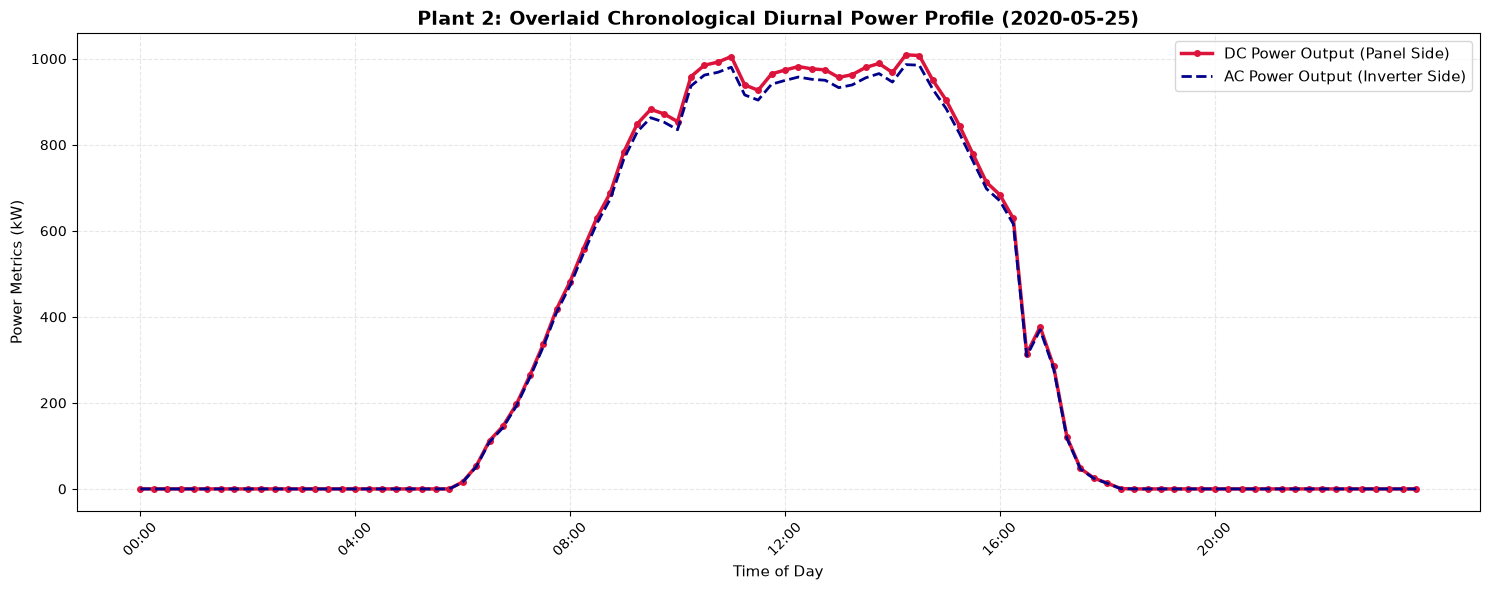

/var/folders/vd/3z40pz013hz0wjckp9xwk7hh0000gn/T/ipykernel_41478/2618483582.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax1.set_xticklabels(daily_summary['DATE_STR'], rotation=90, fontsize=9)


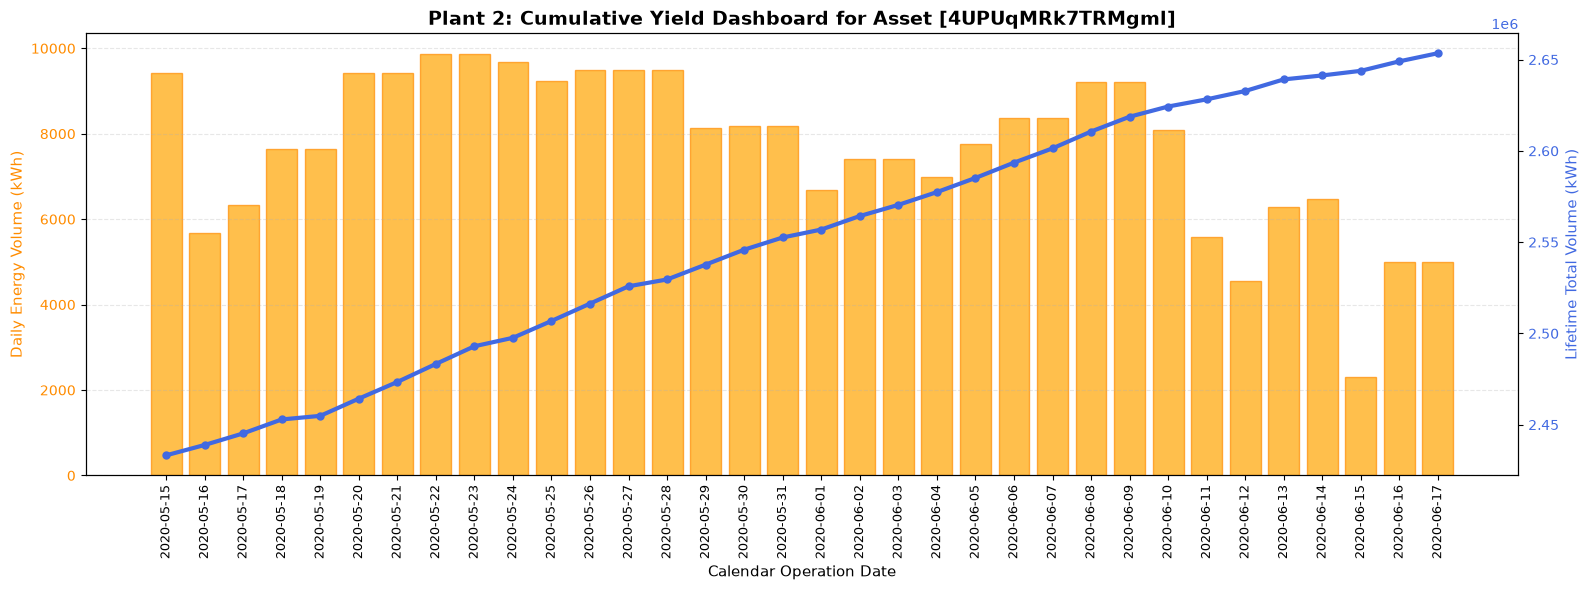

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================================
# PLANT 2: BASELINE RAW DATA EXPLORATION (GEN & WEATHER ISOLATION)
# ==============================================================================

# 1. Load completely raw datasets separately
gen_p2 = pd.read_csv('../data/raw/Plant_2_Generation_Data.csv')
weather_p2 = pd.read_csv('../data/raw/Plant_2_Weather_Sensor_Data.csv')

# Enforce standard datetime structures
gen_p2['DATE_TIME'] = pd.to_datetime(gen_p2['DATE_TIME'])
weather_p2['DATE_TIME'] = pd.to_datetime(weather_p2['DATE_TIME'])

# Create dedicated string format keys for visualization
gen_p2['DATE_STR'] = gen_p2['DATE_TIME'].dt.strftime('%Y-%m-%d')
gen_p2['TIME_STR'] = gen_p2['DATE_TIME'].dt.strftime('%H:%M')


# ------------------------------------------------------------------------------
# STEP 1: Metadata & Feature Information (Dataset Structure)
# ------------------------------------------------------------------------------
print("==============================================================================")
print(" 1. METADATA & FEATURE STRUCTURE REPORT")
print("==============================================================================")
print("\n[ISOLATED DATASET A: GENERATION DATA]")
print(f"Total Database Rows : {gen_p2.shape[0]} rows")
print(f"Available Features  : {list(gen_p2.columns)}")
print("\n--- Raw Head Sample ---")
print(gen_p2.head(3).to_string(index=False))

print("\n" + "="*80)
print("\n[ISOLATED DATASET B: WEATHER SENSOR DATA]")
print(f"Total Database Rows : {weather_p2.shape[0]} rows")
print(f"Available Features  : {list(weather_p2.columns)}")
print("\n--- Raw Head Sample ---")
print(weather_p2.head(3).to_string(index=False))
print("\n" + "="*80 + "\n")


# ------------------------------------------------------------------------------
# STEP 2: Diurnal Power Profile (Overlaid DC_POWER & AC_POWER for a Single Day)
# ------------------------------------------------------------------------------
# Select an arbitrary baseline date to check chronological alignment (e.g., May 25, 2020)
target_sample_date = '2020-05-25'
single_day_gen = gen_p2[gen_p2['DATE_STR'] == target_sample_date].sort_values('DATE_TIME')

# Aggregate by timestamp to compute the cross-sectional mean profiles for the whole plant
single_day_profile = single_day_gen.groupby('TIME_STR')[['DC_POWER', 'AC_POWER']].mean().reset_index()

plt.figure(figsize=(15, 6))
# Overlay DC Power (Primary Left Axis)
plt.plot(single_day_profile['TIME_STR'], single_day_profile['DC_POWER'], 
         color='crimson', lw=2.5, marker='o', ms=4, label='DC Power Output (Panel Side)')

# Overlay AC Power on the identical axis to verify scaling relationships
plt.plot(single_day_profile['TIME_STR'], single_day_profile['AC_POWER'], 
         color='darkblue', lw=2, linestyle='--', label='AC Power Output (Inverter Side)')

# Adjust X-axis label density (Show tick labels every 4 hours / 16 steps of 15 mins)
ax1 = plt.gca()
ax1.set_xticks(ax1.get_xticks()[::16])
plt.xticks(rotation=45)

plt.title(f"Plant 2: Overlaid Chronological Diurnal Power Profile ({target_sample_date})", fontsize=14, fontweight='bold')
plt.xlabel("Time of Day", fontsize=11)
plt.ylabel("Power Metrics (kW)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()


# ==============================================================================
# PLANT 2: YIELD ANALYSIS (DAILY BARS & TOTAL LIFETIME TREND LINE)
# ==============================================================================

# Ensure raw dataset is active
if 'gen_p2' not in locals():
    gen_p2 = pd.read_csv('Plant_2_Generation_Data.csv')
    gen_p2['DATE_TIME'] = pd.to_datetime(gen_p2['DATE_TIME'])
    gen_p2['DATE_STR'] = gen_p2['DATE_TIME'].dt.strftime('%Y-%m-%d')

# ------------------------------------------------------------------------------
# DATA EXTRACTION: Isolate a specific single asset to track its history clean
# ------------------------------------------------------------------------------
target_asset = gen_p2['SOURCE_KEY'].unique()[0]
asset_df = gen_p2[gen_p2['SOURCE_KEY'] == target_asset].sort_values('DATE_TIME')

# Capture the absolute end-of-day maximum record for each metric per day
daily_summary = asset_df.groupby('DATE_STR').agg({
    'DAILY_YIELD': 'max',
    'TOTAL_YIELD': 'max'
}).reset_index()


# ------------------------------------------------------------------------------
# CHART VERSION A: Dual-Axis Overlaid Dashboard (Combined Screen)
# ------------------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(16, 6))

# Left Axis (Y1): Plot Daily Yield as Chronological Orange Bars
ax1.bar(daily_summary['DATE_STR'], daily_summary['DAILY_YIELD'], 
        color='orange', edgecolor='darkorange', alpha=0.7, label='Daily Accumulated Yield (kWh)')
ax1.set_xlabel("Calendar Operation Date", fontsize=11)
ax1.set_ylabel("Daily Energy Volume (kWh)", color='darkorange', fontsize=11)
ax1.tick_params(axis='y', labelcolor='darkorange')
ax1.set_xticklabels(daily_summary['DATE_STR'], rotation=90, fontsize=9)
ax1.grid(True, axis='y', linestyle='--', alpha=0.3)

# Right Axis (Y2): Overlay Lifetime Total Yield as a Continuous Royalblue Line
ax2 = ax1.twinx()
ax2.plot(daily_summary['DATE_STR'], daily_summary['TOTAL_YIELD'], 
         color='royalblue', lw=3, marker='o', ms=5, label='Lifetime Total Yield (Cumulative kWh)')
ax2.set_ylabel("Lifetime Total Volume (kWh)", color='royalblue', fontsize=11)
ax2.tick_params(axis='y', labelcolor='royalblue')

# Apply unified formatting rules
plt.title(f"Plant 2: Cumulative Yield Dashboard for Asset [{target_asset}]", fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()


 2. WEATHER SENSOR DATA - SUMMARY STATISTICS
       AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  IRRADIATION
count          3259.000000         3259.000000  3259.000000
mean             28.069400           32.772408     0.232737
std               4.061556           11.344034     0.312693
min              20.942385           20.265123     0.000000
25%              24.602135           23.716881     0.000000
50%              26.981263           27.534606     0.019040
75%              31.056757           40.480653     0.438717
max              39.181638           66.635953     1.098766




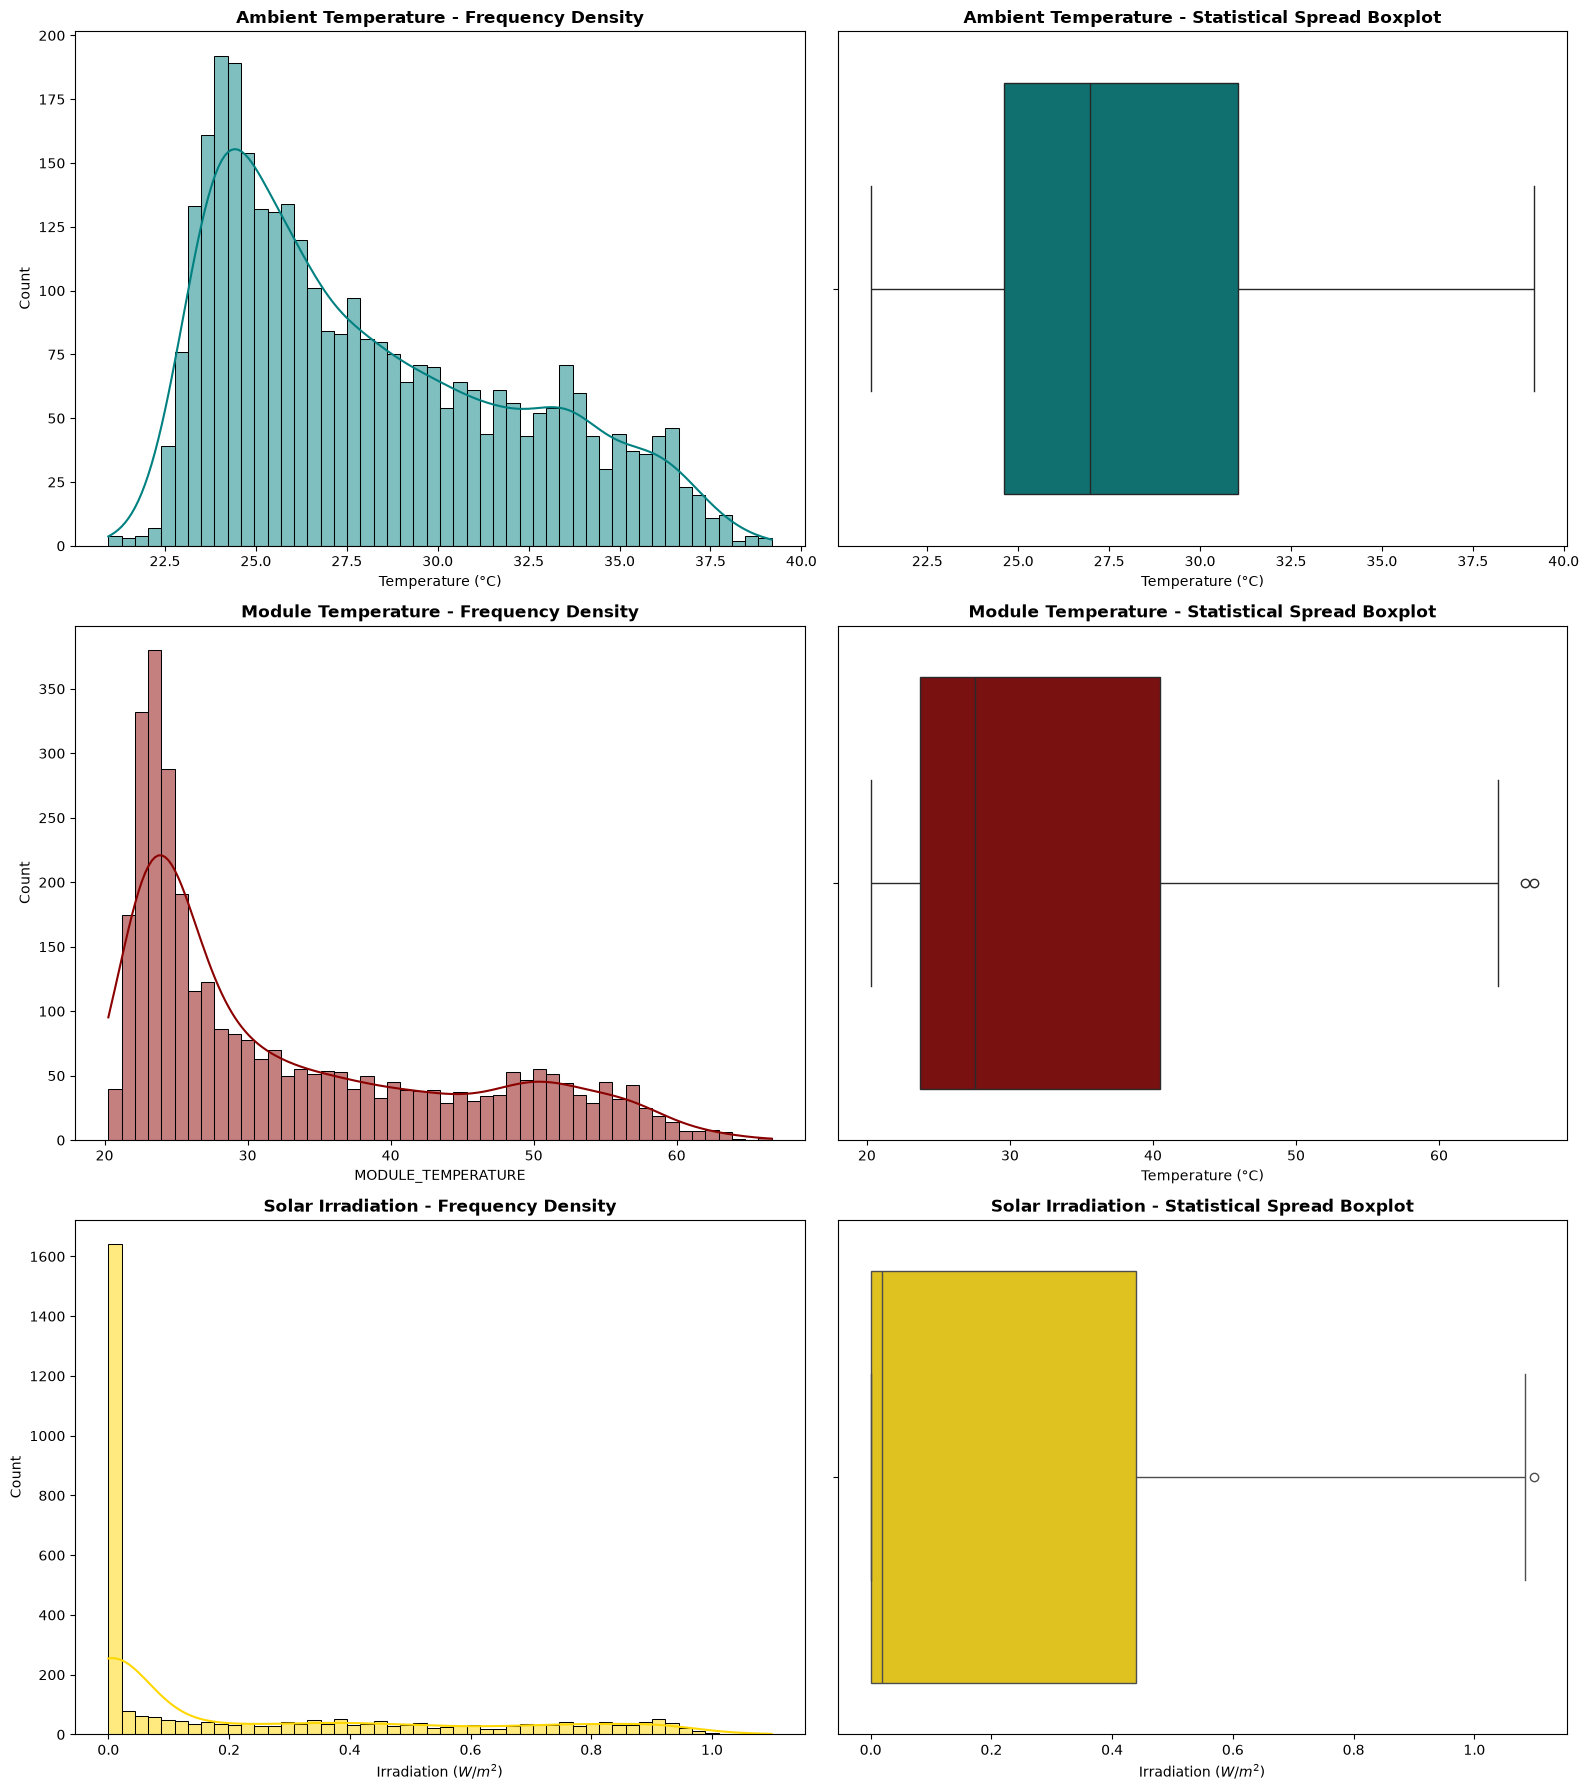

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# PLANT 2: SUMMARY STATISTICS & SENSOR DISTRIBUTION ANALYSIS
# ==============================================================================


# ------------------------------------------------------------------------------
# STEP 1: ISOLATED DESCRIPTIVE STATISTICS (Numerical Verifications)
# ------------------------------------------------------------------------------


print("\n" + "="*80)
print(" 2. WEATHER SENSOR DATA - SUMMARY STATISTICS")
print("==============================================================================")
# Target vectors for atmospheric data profiles
weather_metrics = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
print(weather_p2[weather_metrics].describe().to_string())
print("\n" + "="*80 + "\n")


# ------------------------------------------------------------------------------
# STEP 2: METRIC DISTRIBUTION VISUALIZATION (Histograms & Boxplots)
# ------------------------------------------------------------------------------
# Set up a structured plotting grid for the three primary weather sensors
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Define color themes for distinct physical properties
colors = {'AMBIENT': 'teal', 'MODULE': 'darkred', 'IRRADIATION': 'gold'}

# --- FEATURE A: AMBIENT TEMPERATURE (Surrounding Air) ---
# Left: Histogram with Kernel Density Estimate (KDE) curve
sns.histplot(weather_p2['AMBIENT_TEMPERATURE'], bins=50, kde=True, 
             color=colors['AMBIENT'], ax=axes[0, 0], edgecolor='black')
axes[0, 0].set_title("Ambient Temperature - Frequency Density", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Temperature (°C)")

# Right: Boxplot to audit median limits and statistical outliers
sns.boxplot(x=weather_p2['AMBIENT_TEMPERATURE'], color=colors['AMBIENT'], ax=axes[0, 1])
axes[0, 1].set_title("Ambient Temperature - Statistical Spread Boxplot", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Temperature (°C)")


# --- FEATURE B: MODULE TEMPERATURE (Panel Surface Heat) ---
# Left: Histogram to isolate operational thermal clusters
sns.histplot(weather_p2['MODULE_TEMPERATURE'], bins=50, kde=True, 
             color=colors['MODULE'], ax=axes[1, 0], edgecolor='black')
axes[1, 0].set_title("Module Temperature - Frequency Density", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Temperature (°C)")

# Right: Boxplot to check upper extreme heat variations
sns.boxplot(x=weather_p2['MODULE_TEMPERATURE'], color=colors['MODULE'], ax=axes[1, 1])
axes[1, 1].set_title("Module Temperature - Statistical Spread Boxplot", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Temperature (°C)")


# --- FEATURE C: SOLAR IRRADIATION (Sunlight Intensity) ---
# Left: Histogram mapping daytime transitions vs nocturnal zero-states
sns.histplot(weather_p2['IRRADIATION'], bins=50, kde=True, 
             color=colors['IRRADIATION'], ax=axes[2, 0], edgecolor='black')
axes[2, 0].set_title("Solar Irradiation - Frequency Density", fontsize=12, fontweight='bold')
axes[2, 0].set_xlabel("Irradiation ($W/m^2$)")

# Right: Boxplot highlighting operational sunlight distributions
sns.boxplot(x=weather_p2['IRRADIATION'], color=colors['IRRADIATION'], ax=axes[2, 1])
axes[2, 1].set_title("Solar Irradiation - Statistical Spread Boxplot", fontsize=12, fontweight='bold')
axes[2, 1].set_xlabel("Irradiation ($W/m^2$)")

plt.tight_layout()
plt.show()

 GENERATION METRICS - CORE SUMMARY STATISTICS
           DC_POWER      AC_POWER
count  67698.000000  67698.000000
mean     246.701961    241.277825
std      370.569597    362.112118
min        0.000000      0.000000
25%        0.000000      0.000000
50%        0.000000      0.000000
75%      446.591667    438.215000
max     1420.933333   1385.420000



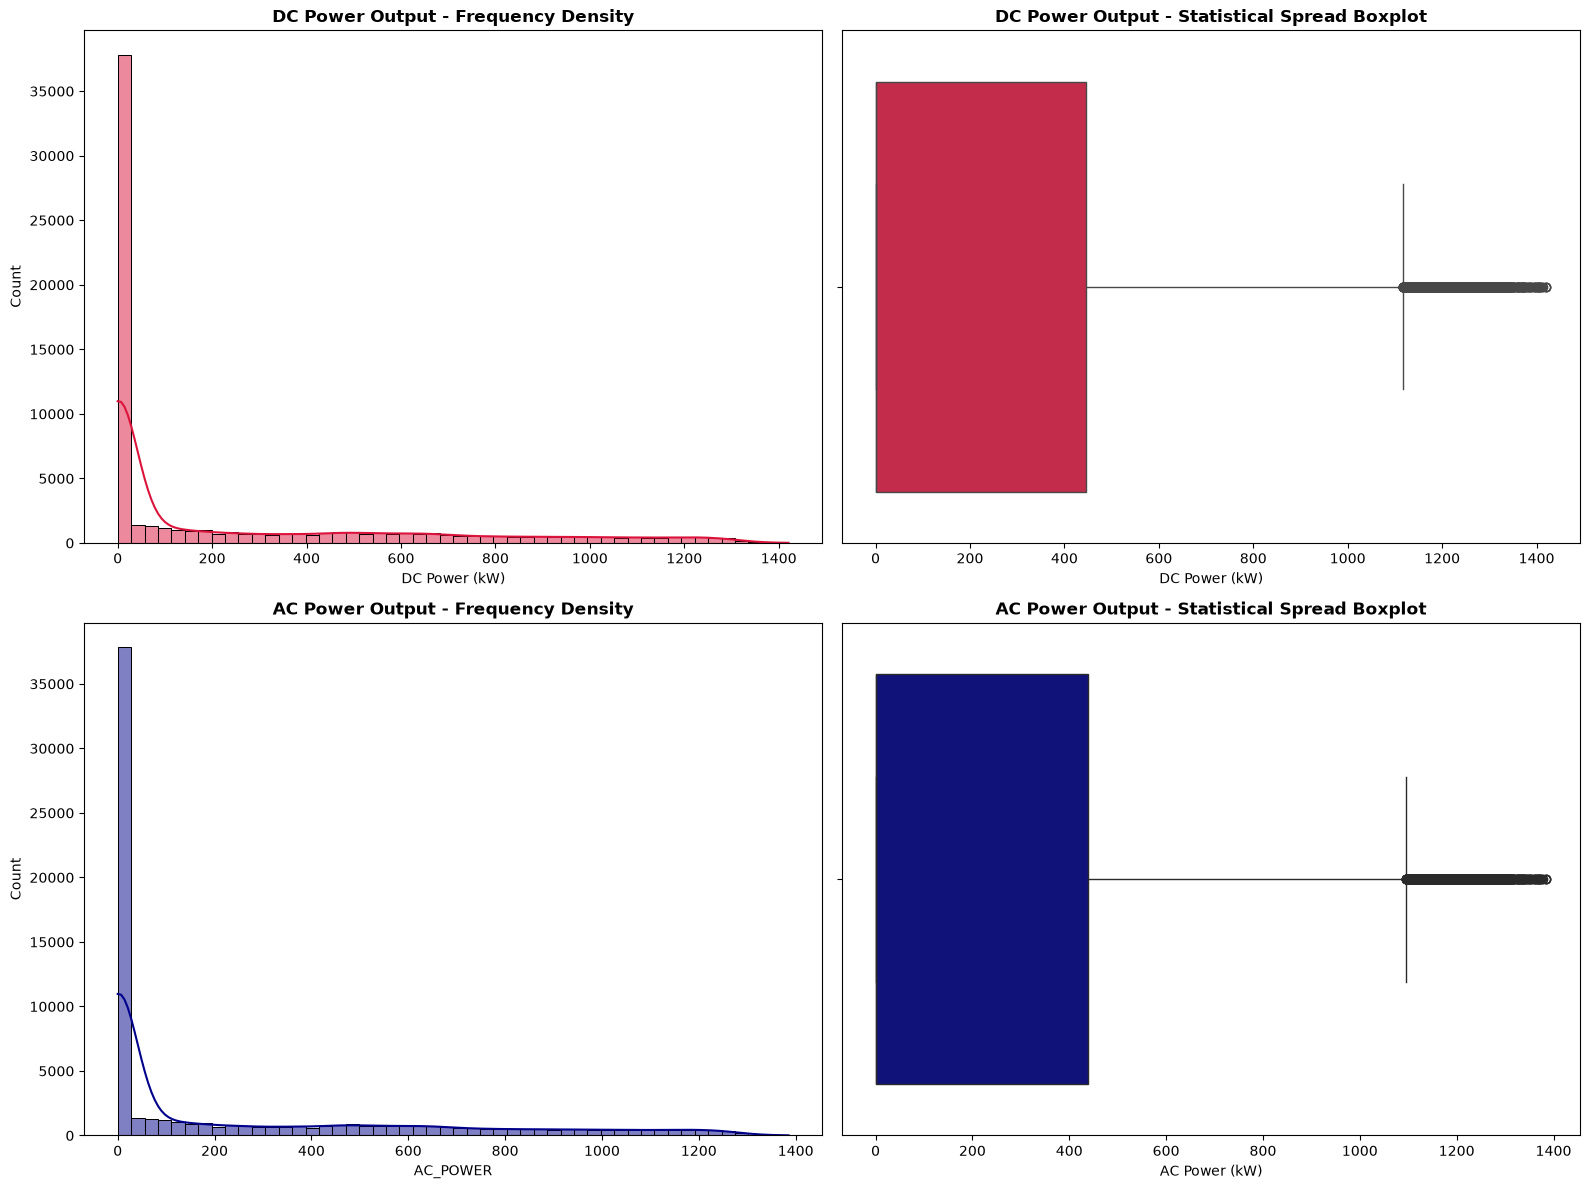

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# PLANT 2: POWER METRICS GENERATION PROFILE (DC VS AC AUDIT)
# ==============================================================================

# Ensure dataset is active (using isolated generation matrix)
if 'gen_p2' not in locals():
    gen_p2 = pd.read_csv('Plant_2_Generation_Data.csv')
    gen_p2['DATE_TIME'] = pd.to_datetime(gen_p2['DATE_TIME'])

# ------------------------------------------------------------------------------
# STEP 1: DESCRIPTIVE STATISTICS SIGN-OFF
# ------------------------------------------------------------------------------
print("==============================================================================")
print(" GENERATION METRICS - CORE SUMMARY STATISTICS")
print("==============================================================================")
power_metrics = ['DC_POWER', 'AC_POWER']
print(gen_p2[power_metrics].describe().to_string())
print("==============================================================================\n")


# ------------------------------------------------------------------------------
# STEP 2: POWER DISTRIBUTION VISUALIZATION (Histograms & Boxplots)
# ------------------------------------------------------------------------------
# Setup a 2x2 grid framework to align DC and AC distributions symmetrically
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

power_colors = {'DC': 'crimson', 'AC': 'darkblue'}

# --- FEATURE A: DC POWER (Panel Surface Generation) ---
# Left: Frequency density distribution for DC
sns.histplot(gen_p2['DC_POWER'], bins=50, kde=True, 
             color=power_colors['DC'], ax=axes[0, 0], edgecolor='black')
axes[0, 0].set_title("DC Power Output - Frequency Density", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("DC Power (kW)")

# Right: Boxplot to check outlier boundaries and maximum limits
sns.boxplot(x=gen_p2['DC_POWER'], color=power_colors['DC'], ax=axes[0, 1])
axes[0, 1].set_title("DC Power Output - Statistical Spread Boxplot", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("DC Power (kW)")


# --- FEATURE B: AC POWER (Post-Inverter Grid Output) ---
# Left: Frequency density distribution for AC
sns.histplot(gen_p2['AC_POWER'], bins=50, kde=True, 
             color=power_colors['AC'], ax=axes[1, 0], edgecolor='black')
axes[1, 0].set_title("AC Power Output - Frequency Density", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("AC Power (kW)")

# Right: Boxplot to analyze median operational alignment
sns.boxplot(x=gen_p2['AC_POWER'], color=power_colors['AC'], ax=axes[1, 1])
axes[1, 1].set_title("AC Power Output - Statistical Spread Boxplot", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("AC Power (kW)")

plt.tight_layout()
plt.show()

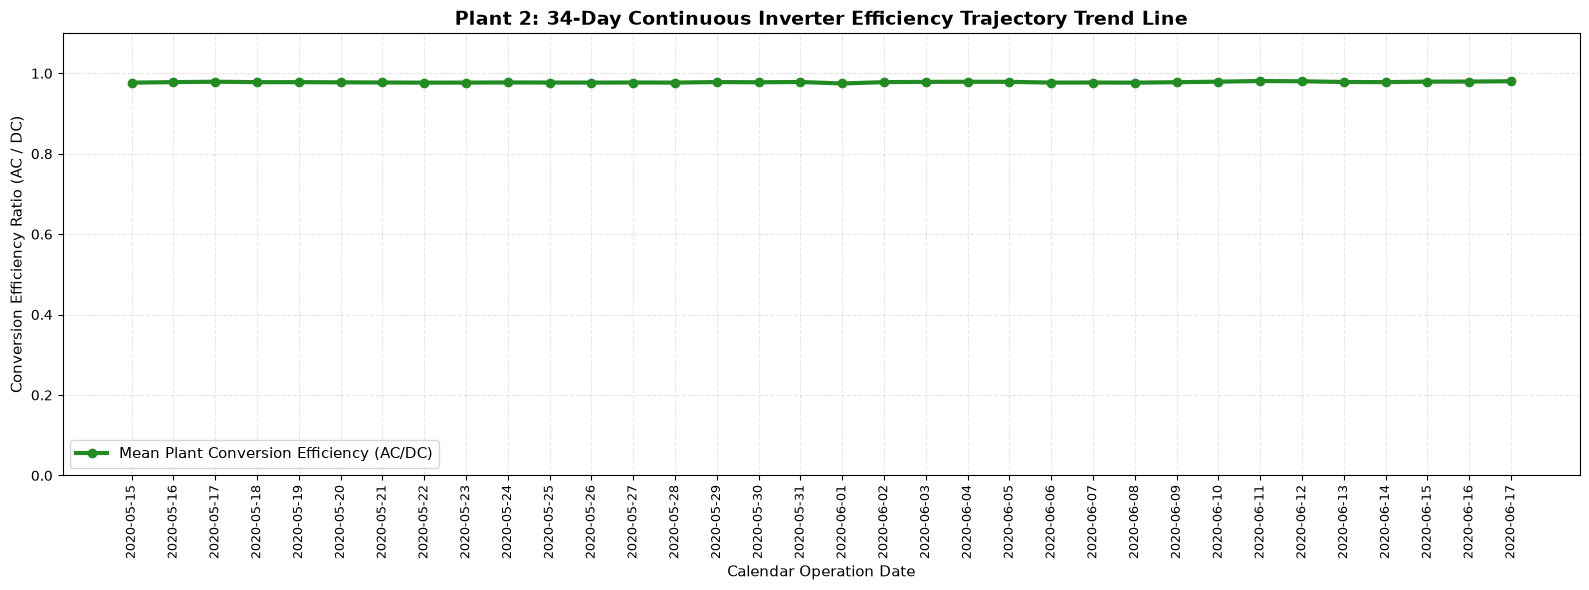

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================================
# PLANT 2: 34-DAY INVERTER EFFICIENCY TIMELINE ANALYSIS
# ==============================================================================

# Ensure raw dataset is active
if 'gen_p2' not in locals():
    gen_p2 = pd.read_csv('Plant_2_Generation_Data.csv')
    gen_p2['DATE_TIME'] = pd.to_datetime(gen_p2['DATE_TIME'])
    gen_p2['DATE_STR'] = gen_p2['DATE_TIME'].dt.strftime('%Y-%m-%d')
    gen_p2['TIME_STR'] = gen_p2['DATE_TIME'].dt.strftime('%H:%M')

# 1. FILTERING SAFEGUARD: Isolate peak daylight hours to eliminate zero-division at night
# We filter strictly between 09:00 AM and 04:00 PM when generation is stable
daylight_df = gen_p2[(gen_p2['TIME_STR'] >= '09:00') & (gen_p2['TIME_STR'] <= '16:00')].copy()

# Ensure we drop any random rows where DC_POWER is exactly 0 to avoid zero-division errors
daylight_df = daylight_df[daylight_df['DC_POWER'] > 0]

# 2. CALCULATE EFFICIENCY: Apply the domain ratio rule (AC / DC)
daylight_df['EFFICIENCY'] = daylight_df['AC_POWER'] / daylight_df['DC_POWER']

# 3. CHRONOLOGICAL AGGREGATION: Compute the mean efficiency for the entire plant per day
daily_efficiency = daylight_df.groupby('DATE_STR')['EFFICIENCY'].mean().reset_index()

# 4. PLOT TIMELINE TREND LINE
plt.figure(figsize=(16, 6))

# Plot the 34-day operational trajectory
plt.plot(daily_efficiency['DATE_STR'], daily_efficiency['EFFICIENCY'], 
         color='forestgreen', lw=3, marker='o', ms=6, label='Mean Plant Conversion Efficiency (AC/DC)')

# Set strict Y-axis limits matching real-world physical boundaries
plt.ylim(0.0, 1.1)  # Efficiency scales between 0% and 110% (captures scaling characteristics)

plt.xticks(rotation=90, fontsize=9)
plt.title("Plant 2: 34-Day Continuous Inverter Efficiency Trajectory Trend Line", fontsize=14, fontweight='bold')
plt.xlabel("Calendar Operation Date", fontsize=11)
plt.ylabel("Conversion Efficiency Ratio (AC / DC)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='lower left', fontsize=11)
plt.tight_layout()
plt.show()

In [7]:
import pandas as pd

# ==============================================================================
# PLANT 2: ISOLATED MISSING VALUE (NULL/NAN) OPERATIONAL AUDIT
# ==============================================================================

# 1. Enforce active memory allocation for completely raw data assets
if 'gen_p2' not in locals() or 'weather_p2' not in locals():
    gen_p2 = pd.read_csv('Plant_2_Generation_Data.csv')
    weather_p2 = pd.read_csv('Plant_2_Weather_Sensor_Data.csv')

# ------------------------------------------------------------------------------
# AUDIT BLOCK A: GENERATION DATA MATRIX
# ------------------------------------------------------------------------------
# Calculate absolute null counts and map them to their percentage weights
gen_null_counts = gen_p2.isnull().sum()
gen_null_pcts   = (gen_p2.isnull().sum() / len(gen_p2)) * 100

gen_audit_table = pd.DataFrame({
    'Feature_Name': gen_null_counts.index,
    'Total_Null_Rows': gen_null_counts.values,
    'Missing_Ratio(%)': gen_null_pcts.values
})

print("==============================================================================")
print(" AUDIT REPORT A: PLANT 2 GENERATION DATASET INTEGRITY SIGN-OFF")
print("==============================================================================")
print(gen_audit_table.to_string(index=False, formatters={'Missing_Ratio(%)': '{:.4f}%'.format}))
print(f"--> Total Rows Scanned: {len(gen_p2):,} rows")
print("==============================================================================\n")


# ------------------------------------------------------------------------------
# AUDIT BLOCK B: WEATHER SENSOR DATA MATRIX
# ------------------------------------------------------------------------------
# Calculate absolute null counts and map them to their percentage weights
weather_null_counts = weather_p2.isnull().sum()
weather_null_pcts   = (weather_p2.isnull().sum() / len(weather_p2)) * 100

weather_audit_table = pd.DataFrame({
    'Feature_Name': weather_null_counts.index,
    'Total_Null_Rows': weather_null_counts.values,
    'Missing_Ratio(%)': weather_null_pcts.values
})

print("==============================================================================")
print(" AUDIT REPORT B: PLANT 2 WEATHER SENSOR DATASET INTEGRITY SIGN-OFF")
print("==============================================================================")
print(weather_audit_table.to_string(index=False, formatters={'Missing_Ratio(%)': '{:.4f}%'.format}))
print(f"--> Total Rows Scanned: {len(weather_p2):,} rows")
print("==============================================================================")

 AUDIT REPORT A: PLANT 2 GENERATION DATASET INTEGRITY SIGN-OFF
Feature_Name  Total_Null_Rows Missing_Ratio(%)
   DATE_TIME                0          0.0000%
    PLANT_ID                0          0.0000%
  SOURCE_KEY                0          0.0000%
    DC_POWER                0          0.0000%
    AC_POWER                0          0.0000%
 DAILY_YIELD                0          0.0000%
 TOTAL_YIELD                0          0.0000%
    DATE_STR                0          0.0000%
    TIME_STR                0          0.0000%
--> Total Rows Scanned: 67,698 rows

 AUDIT REPORT B: PLANT 2 WEATHER SENSOR DATASET INTEGRITY SIGN-OFF
       Feature_Name  Total_Null_Rows Missing_Ratio(%)
          DATE_TIME                0          0.0000%
           PLANT_ID                0          0.0000%
         SOURCE_KEY                0          0.0000%
AMBIENT_TEMPERATURE                0          0.0000%
 MODULE_TEMPERATURE                0          0.0000%
        IRRADIATION                0   

 CRITICAL AUDIT 1: MIDNIGHT RESET FAILURES DETECTED
Notice how some inverters carry over thousands of kWh instead of resetting to 0.00:
  DATE_STR      SOURCE_KEY  DAILY_YIELD
2020-05-15 4UPUqMRk7TRMgml  9425.000000
2020-05-15 81aHJ1q11NBPMrL     0.000000
2020-05-15 9kRcWv60rDACzjR  3075.333333
2020-05-15 Et9kgGMDl729KT4   269.933333
2020-05-15 IQ2d7wF4YD8zU1Q  3177.000000
2020-05-15 LYwnQax7tkwH5Cb  1872.500000



/var/folders/vd/3z40pz013hz0wjckp9xwk7hh0000gn/T/ipykernel_41478/464376561.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


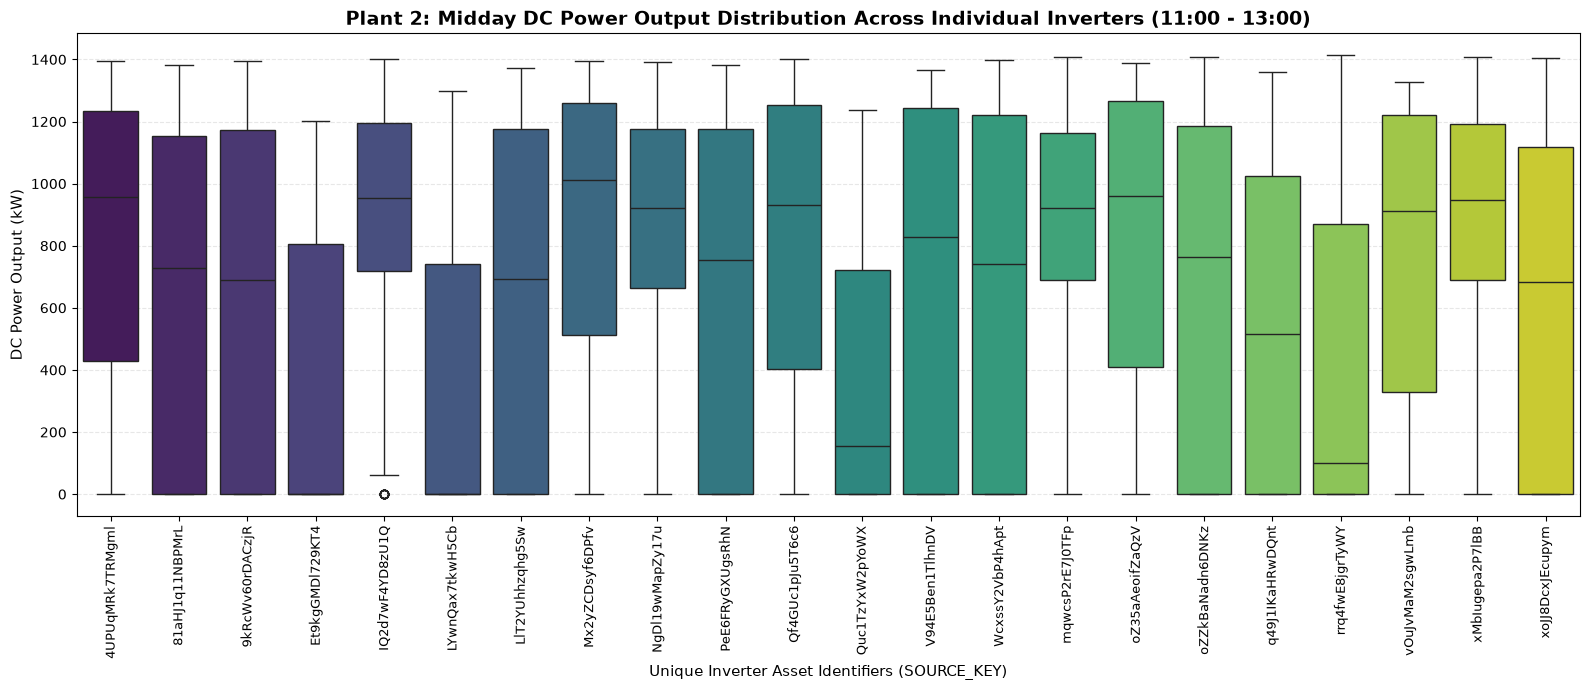

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# PLANT 2: ADVANCED EDA - HARDWARE ANOMALIES & RESET BUGS
# ==============================================================================

# Ensure raw dataset is active
if 'gen_p2' not in locals():
    gen_p2 = pd.read_csv('Plant_2_Generation_Data.csv')
    gen_p2['DATE_TIME'] = pd.to_datetime(gen_p2['DATE_TIME'])
    gen_p2['DATE_STR'] = gen_p2['DATE_TIME'].dt.strftime('%Y-%m-%d')
    gen_p2['TIME_STR'] = gen_p2['DATE_TIME'].dt.strftime('%H:%M')

# ------------------------------------------------------------------------------
# PROOF 1: Midnight Reset Bug Detection (深夜のリセットバグを目視する)
# ------------------------------------------------------------------------------
# Extract midnight entries (00:00 AM) across all unique inverter assets
midnight_df = gen_p2[gen_p2['TIME_STR'] == '00:00'].sort_values(['DATE_STR', 'SOURCE_KEY'])

print("==============================================================================")
print(" CRITICAL AUDIT 1: MIDNIGHT RESET FAILURES DETECTED")
print("==============================================================================")
print("Notice how some inverters carry over thousands of kWh instead of resetting to 0.00:")
print(midnight_df[['DATE_STR', 'SOURCE_KEY', 'DAILY_YIELD']].head(6).to_string(index=False))
print("==============================================================================\n")


# ------------------------------------------------------------------------------
# PROOF 2: Inverter Performance Disparity (インバーターごとのサボり・ばらつき可視化)
# ------------------------------------------------------------------------------
# Filter strictly for peak daylight hours to observe active generation characteristics
peak_daylight = gen_p2[(gen_p2['TIME_STR'] >= '11:00') & (gen_p2['TIME_STR'] <= '13:00')]

plt.figure(figsize=(16, 7))

# Render a categorized boxplot mapping the distribution of DC_POWER for every single inverter
sns.boxplot(
    data=peak_daylight.sort_values('SOURCE_KEY'), 
    x='SOURCE_KEY', 
    y='DC_POWER', 
    palette='viridis'
)

plt.xticks(rotation=90, fontsize=9)
plt.title("Plant 2: Midday DC Power Output Distribution Across Individual Inverters (11:00 - 13:00)", fontsize=14, fontweight='bold')
plt.xlabel("Unique Inverter Asset Identifiers (SOURCE_KEY)", fontsize=11)
plt.ylabel("DC Power Output (kW)", fontsize=11)
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

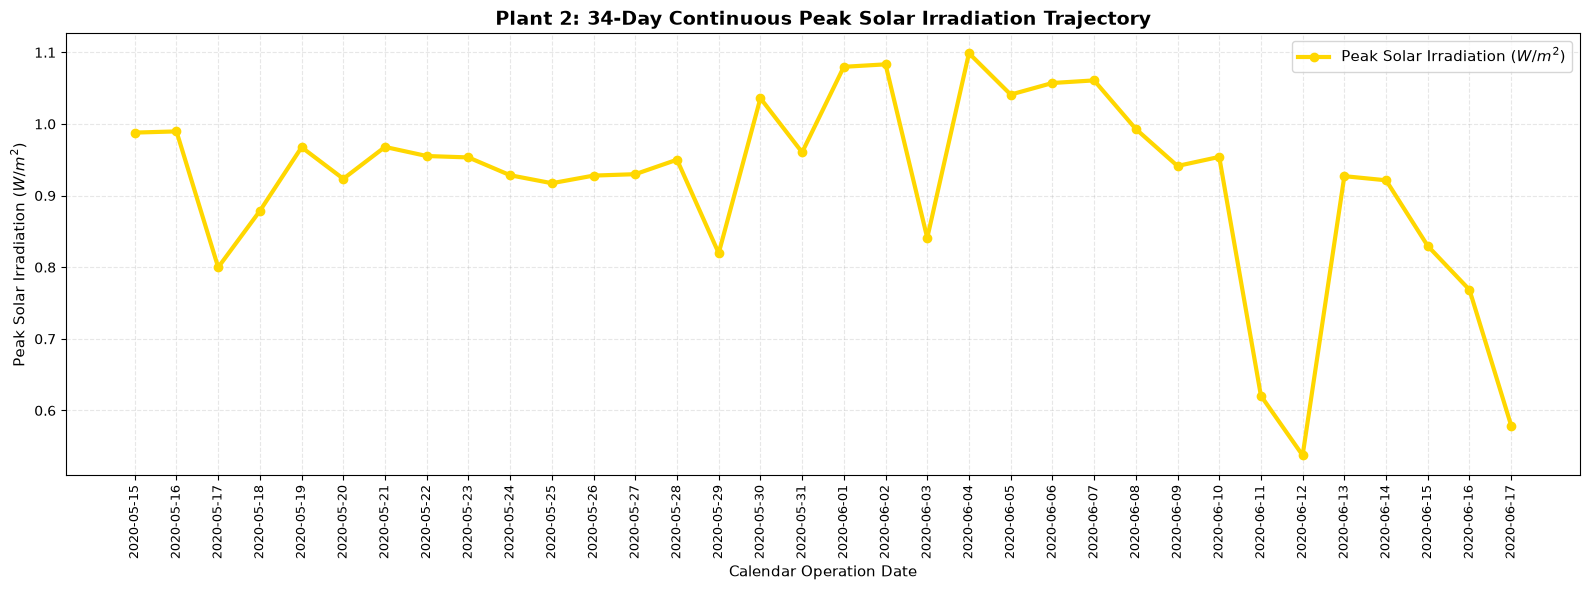

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================================
# CHART 1: 34-DAY SOLAR IRRADIATION METRIC TRAJECTORY (LINE CHART)
# ==============================================================================

# 1. Enforce active memory allocation for raw weather asset
if 'weather_p2' not in locals():
    weather_p2 = pd.read_csv('Plant_2_Weather_Sensor_Data.csv')
    weather_p2['DATE_TIME'] = pd.to_datetime(weather_p2['DATE_TIME'])

# Extract clean date indices for daily groupings
weather_p2['DATE_STR'] = weather_p2['DATE_TIME'].dt.strftime('%Y-%m-%d')

# 2. Extract maximum daily irradiation values to monitor peak sunlight capacity
daily_sun_peaks = weather_p2.groupby('DATE_STR')['IRRADIATION'].max().reset_index()

# 3. Render chronological timeline line chart
plt.figure(figsize=(16, 6))
plt.plot(daily_sun_peaks['DATE_STR'], daily_sun_peaks['IRRADIATION'], 
         color='gold', lw=3, marker='o', ms=6, label='Peak Solar Irradiation ($W/m^2$)')

plt.xticks(rotation=90, fontsize=9)
plt.title("Plant 2: 34-Day Continuous Peak Solar Irradiation Trajectory", fontsize=14, fontweight='bold')
plt.xlabel("Calendar Operation Date", fontsize=11)
plt.ylabel("Peak Solar Irradiation ($W/m^2$)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

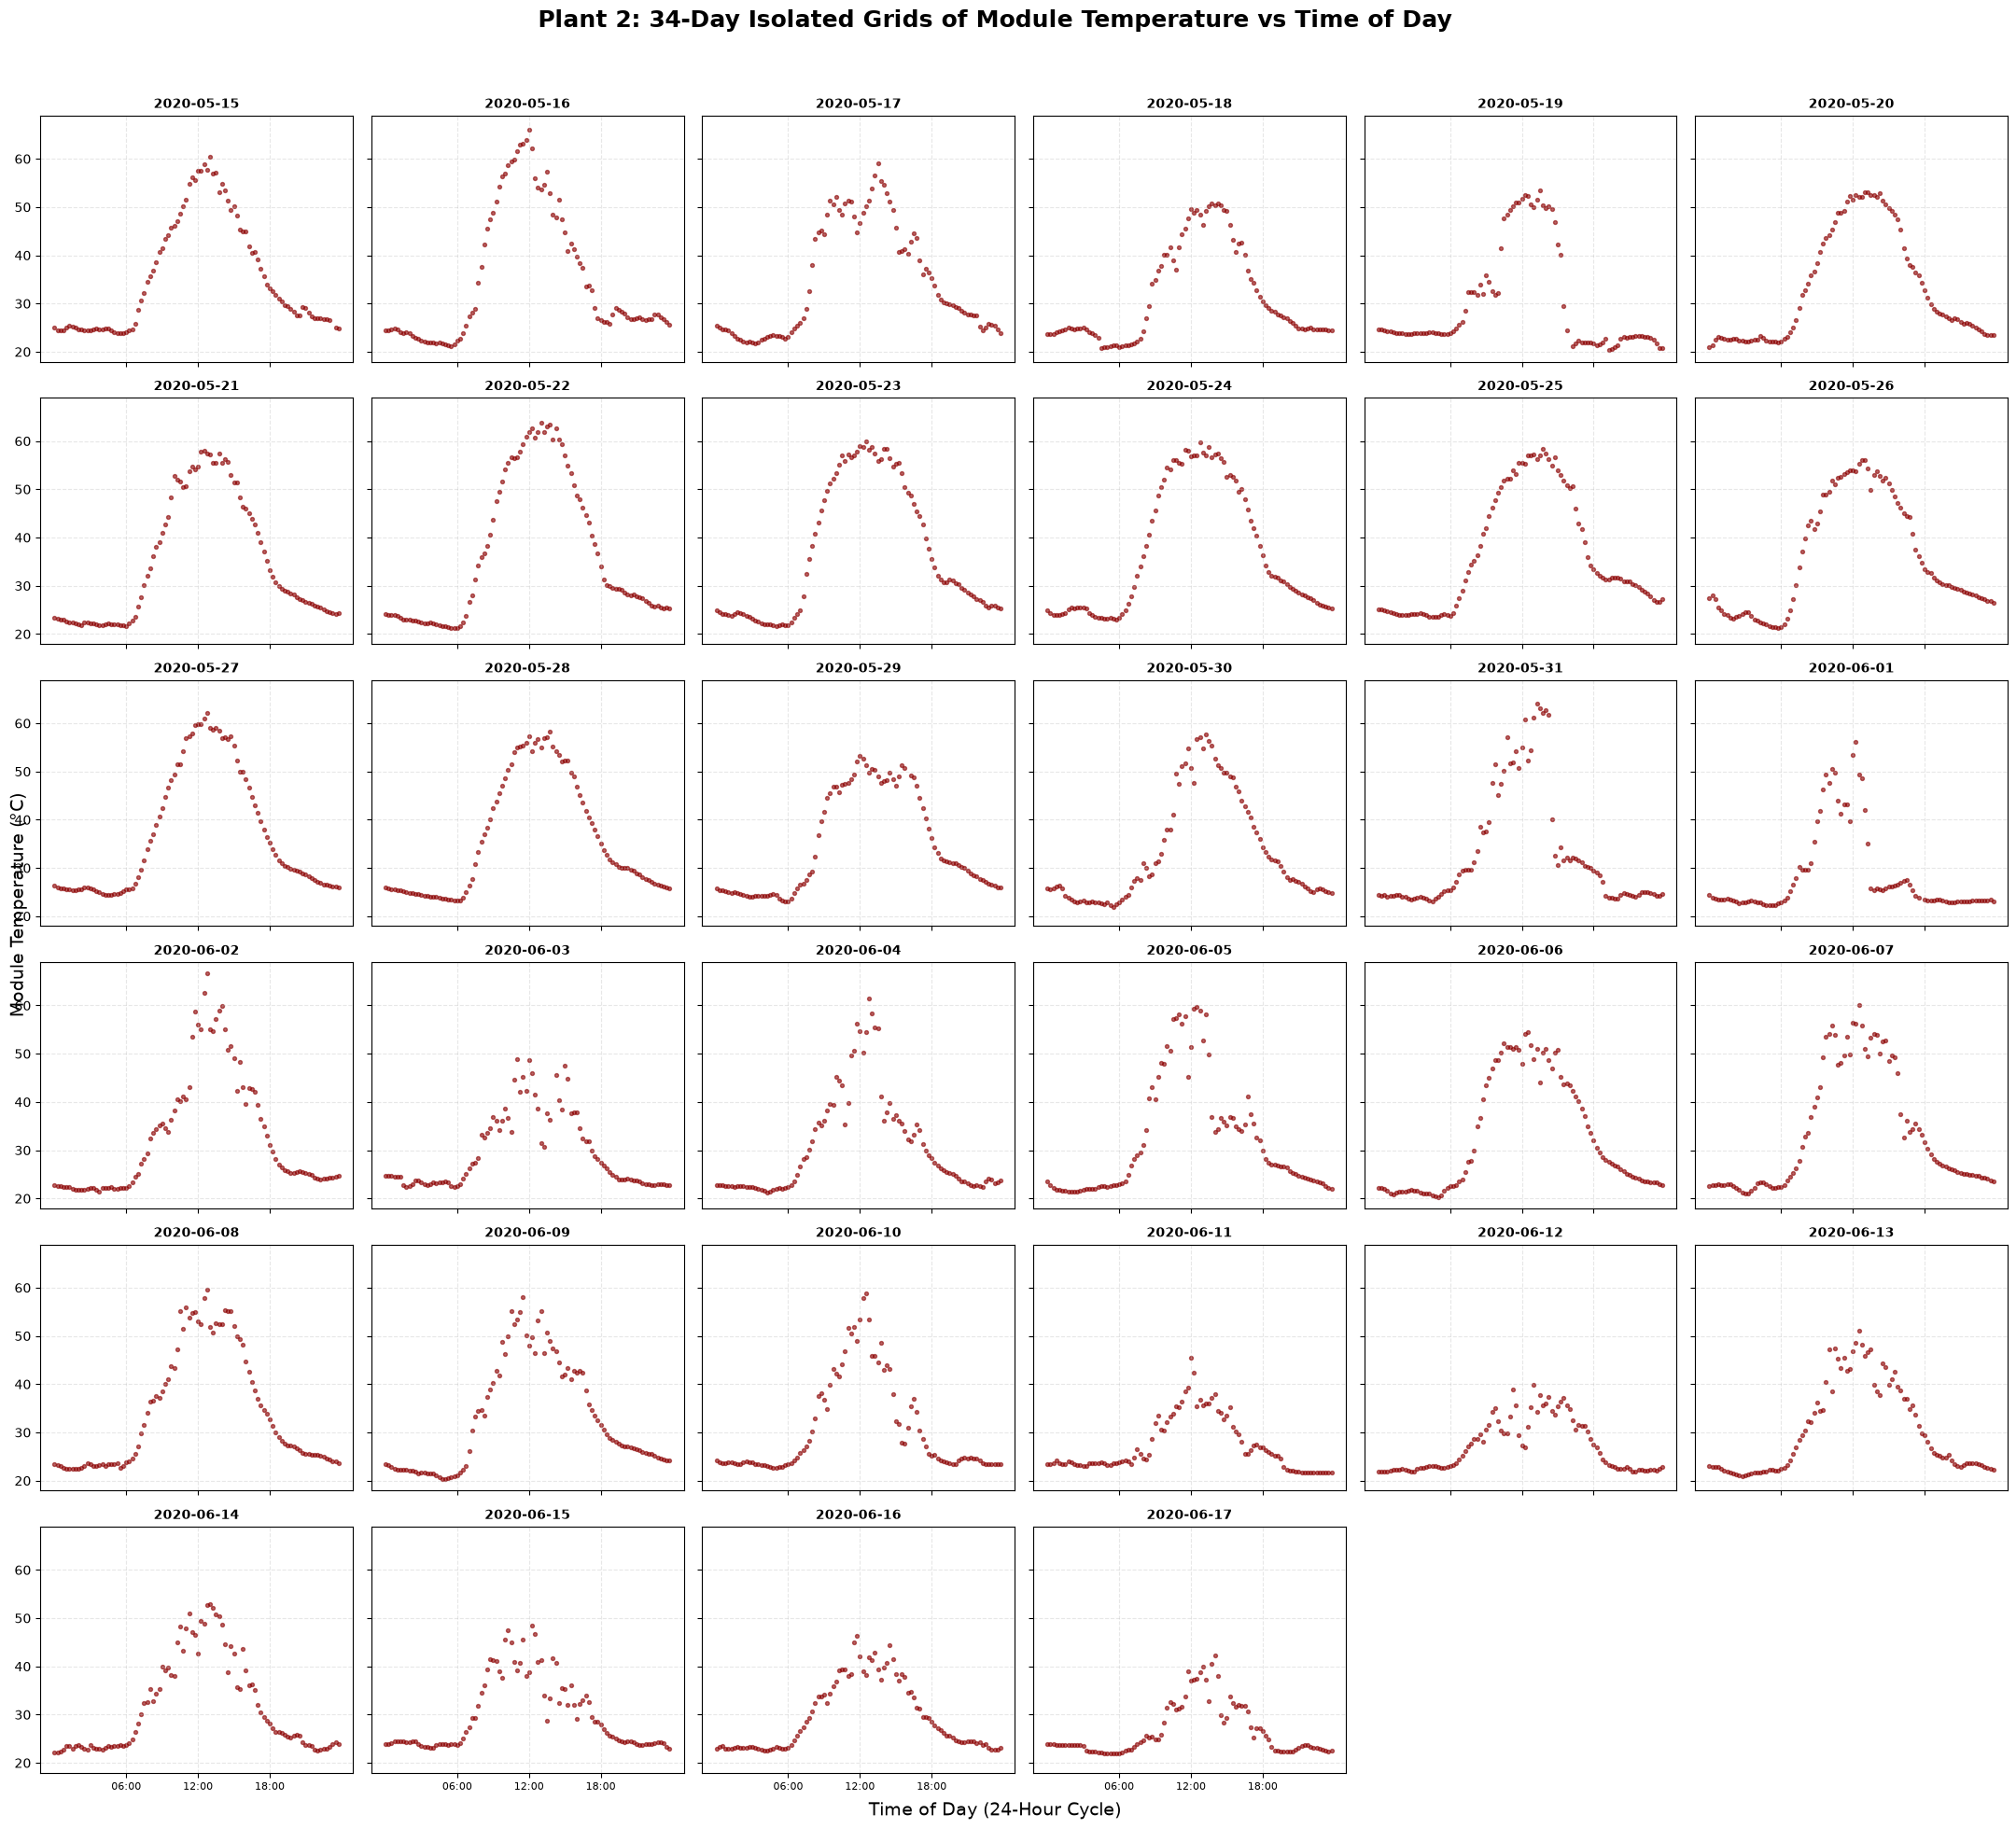

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# BLOCK 2: MODULE TEMPERATURE DIURNAL SCATTER (34-DAY FACETS)
# ==============================================================================

if 'weather_p2' not in locals():
    weather_p2 = pd.read_csv('Plant_2_Weather_Sensor_Data.csv')
    weather_p2['DATE_TIME'] = pd.to_datetime(weather_p2['DATE_TIME'])

# Construct sorting index elements
df_mod = weather_p2.copy()
df_mod['DATE_STR'] = df_mod['DATE_TIME'].dt.strftime('%Y-%m-%d')
df_mod['TIME_MINUTES'] = df_mod['DATE_TIME'].dt.hour * 60 + df_mod['DATE_TIME'].dt.minute

# Identify all distinct calendar days available (34 days)
unique_days = sorted(df_mod['DATE_STR'].unique())

# Initialize a 6x6 grid subplot framework to perfectly encompass 34 targets
fig, axes = plt.subplots(6, 6, figsize=(22, 20), sharex=True, sharey=True)
axes = axes.flatten()

for i, day in enumerate(unique_days):
    day_data = df_mod[df_mod['DATE_STR'] == day]
    ax = axes[i]
    
    # Scatter plot tracking the panel heat development path across 24 hours
    ax.scatter(day_data['TIME_MINUTES'], day_data['MODULE_TEMPERATURE'], 
               color='darkred', alpha=0.6, s=8)
    
    # Clean up localized sub-graph labels
    ax.set_title(day, fontsize=10, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # Set time labels to show basic standard boundaries (6:00, 12:00, 18:00)
    ax.set_xticks([360, 720, 1080])
    ax.set_xticklabels(['06:00', '12:00', '18:00'], fontsize=8)

# Disable empty unused grid plots remaining at the lower edge
for j in range(len(unique_days), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Plant 2: 34-Day Isolated Grids of Module Temperature vs Time of Day", fontsize=18, fontweight='bold', y=0.98)
fig.supxlabel("Time of Day (24-Hour Cycle)", fontsize=14)
fig.supylabel("Module Temperature (°C)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

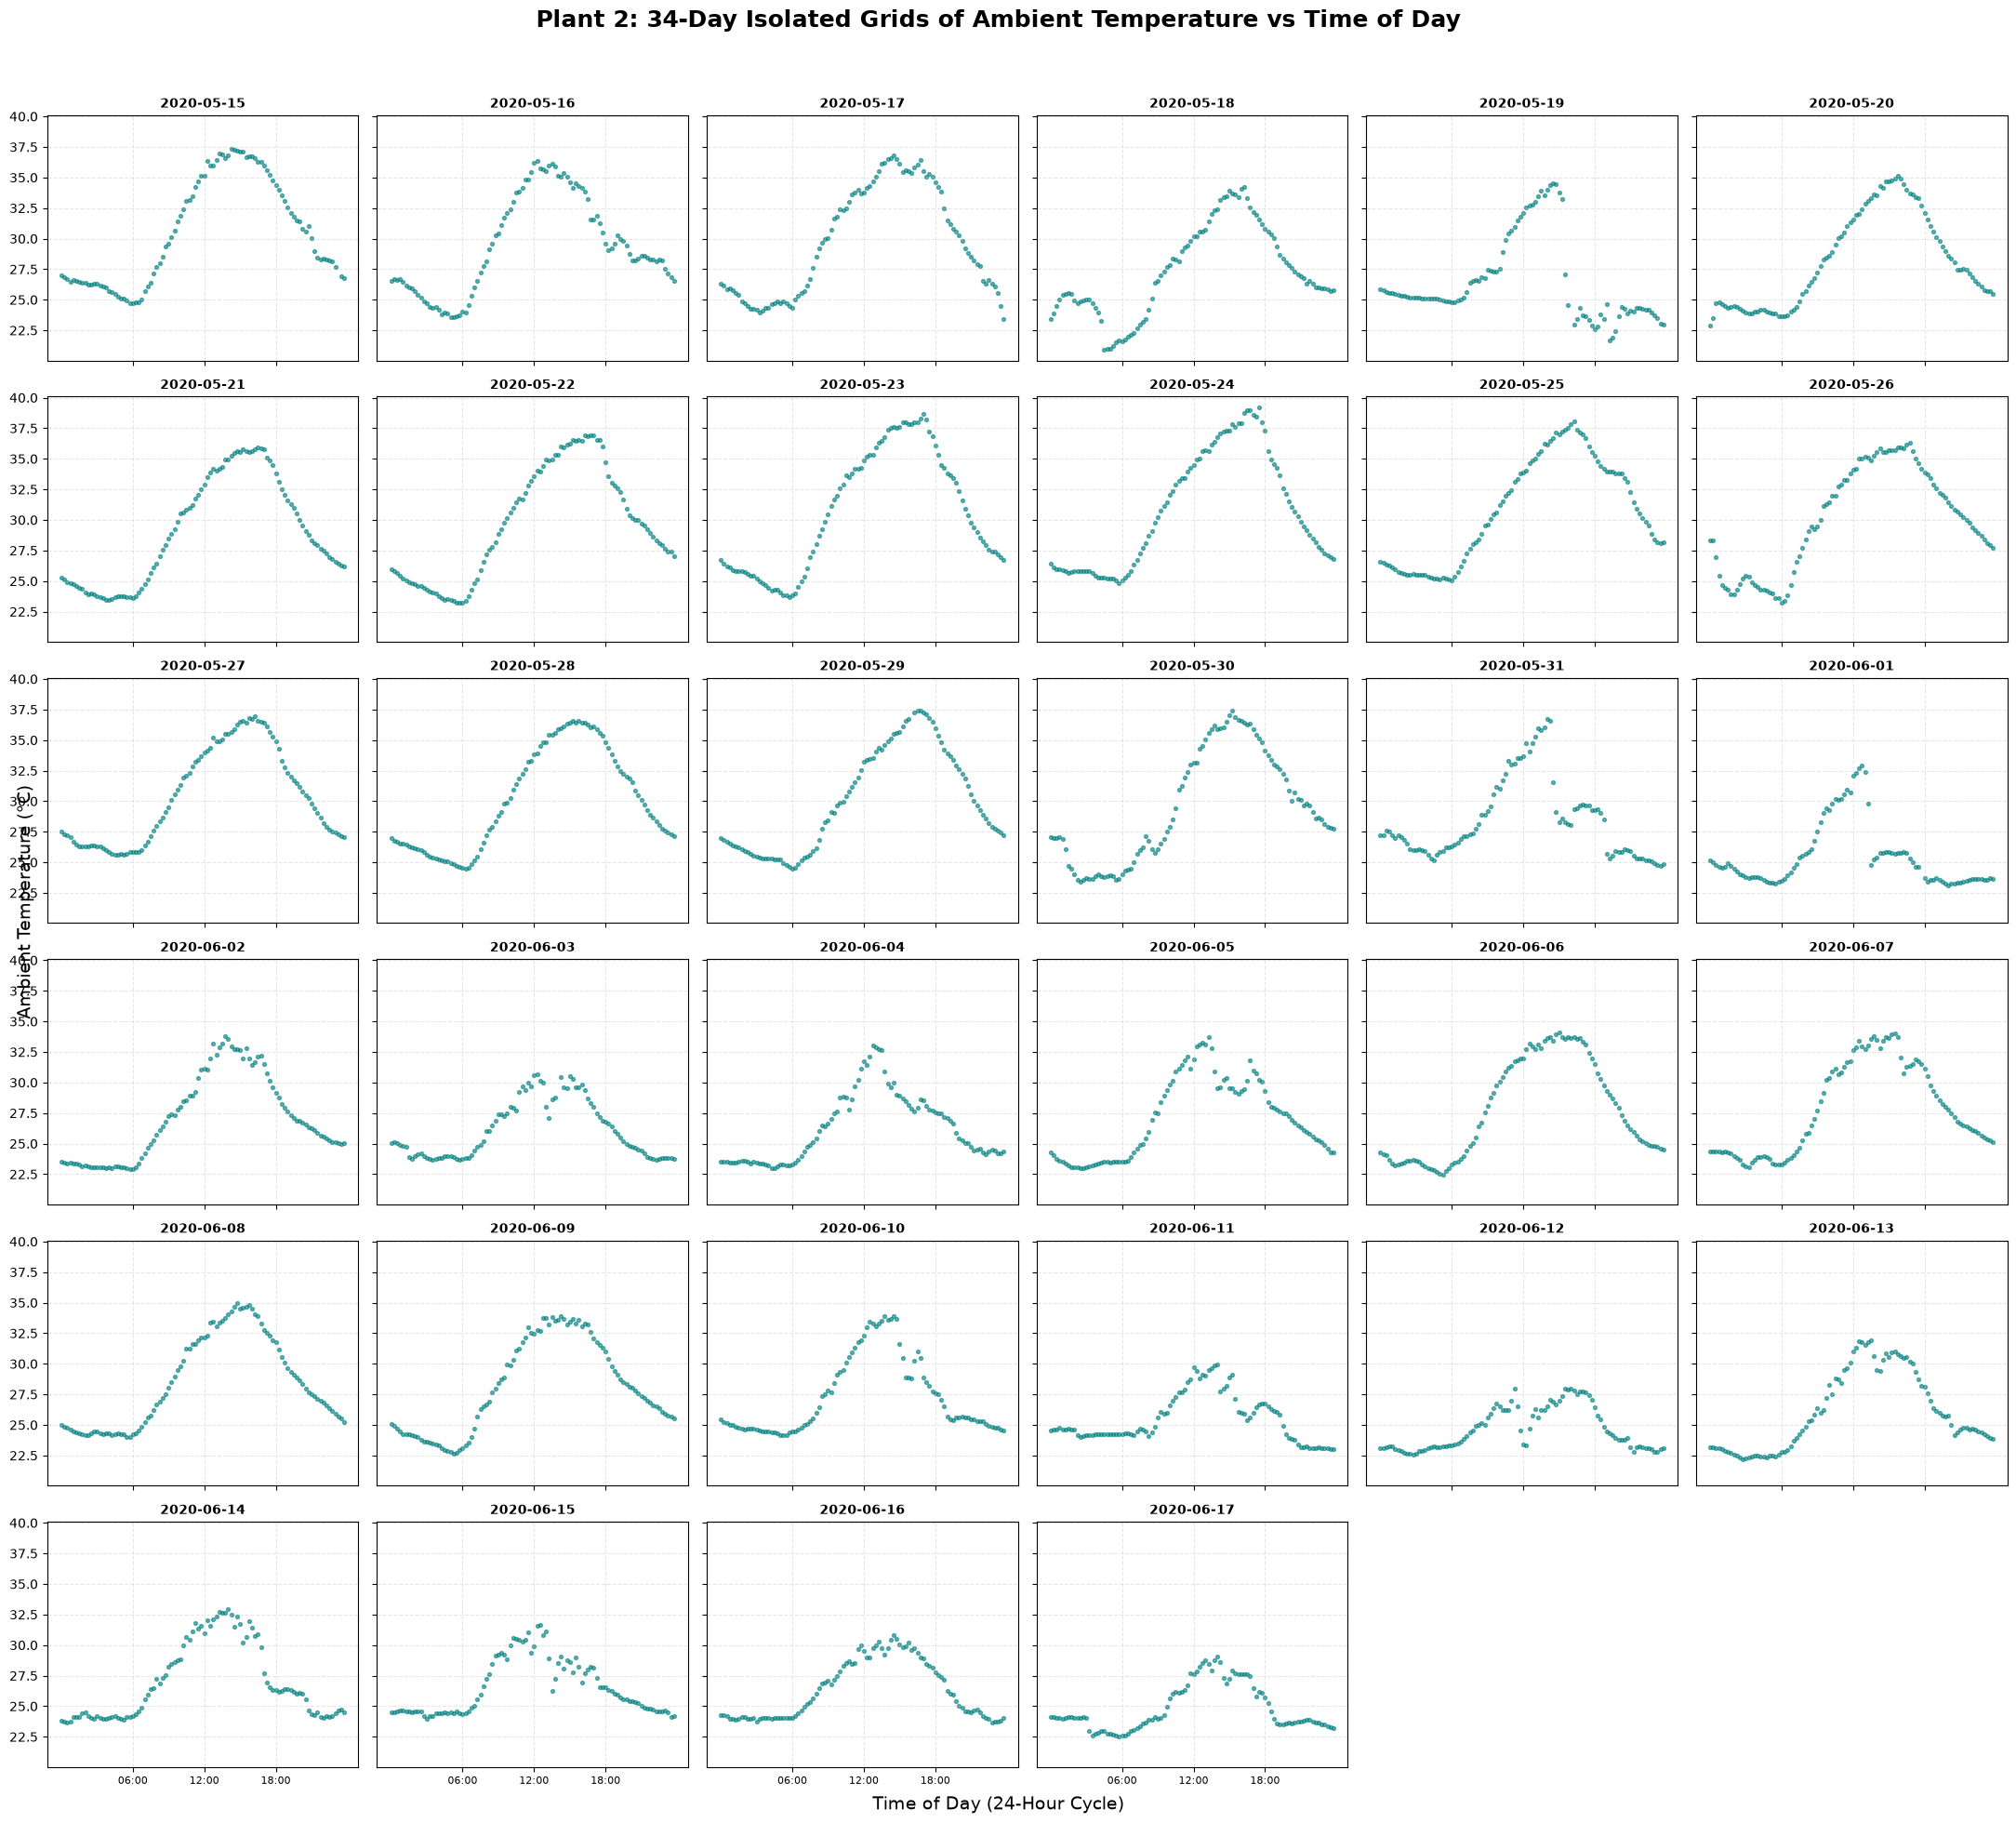

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# BLOCK 3: AMBIENT TEMPERATURE DIURNAL SCATTER (34-DAY FACETS)
# ==============================================================================

if 'weather_p2' not in locals():
    weather_p2 = pd.read_csv('Plant_2_Weather_Sensor_Data.csv')
    weather_p2['DATE_TIME'] = pd.to_datetime(weather_p2['DATE_TIME'])

# Construct sorting index elements
df_amb = weather_p2.copy()
df_amb['DATE_STR'] = df_amb['DATE_TIME'].dt.strftime('%Y-%m-%d')
df_amb['TIME_MINUTES'] = df_amb['DATE_TIME'].dt.hour * 60 + df_amb['DATE_TIME'].dt.minute

unique_days = sorted(df_amb['DATE_STR'].unique())

# Initialize identical 6x6 grid subplot framework
fig, axes = plt.subplots(6, 6, figsize=(22, 20), sharex=True, sharey=True)
axes = axes.flatten()

for i, day in enumerate(unique_days):
    day_data = df_amb[df_amb['DATE_STR'] == day]
    ax = axes[i]
    
    # Scatter plot tracking the ambient air thermal changes across 24 hours
    ax.scatter(day_data['TIME_MINUTES'], day_data['AMBIENT_TEMPERATURE'], 
               color='teal', alpha=0.6, s=8)
    
    ax.set_title(day, fontsize=10, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_xticks([360, 720, 1080])
    ax.set_xticklabels(['06:00', '12:00', '18:00'], fontsize=8)

# Disable empty unused grid plots
for j in range(len(unique_days), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Plant 2: 34-Day Isolated Grids of Ambient Temperature vs Time of Day", fontsize=18, fontweight='bold', y=0.98)
fig.supxlabel("Time of Day (24-Hour Cycle)", fontsize=14)
fig.supylabel("Ambient Temperature (°C)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

 EVIDENCE TABLE: DAILY_YIELD RESET FAILURES AT MIDNIGHT (2020-05-15 00:00 AM)
Look at the highlighted anomalies where features carry over legacy metrics instead of 0.00:
  DATE_STR TIME_STR      SOURCE_KEY DAILY_YIELD
2020-05-15    00:00 4UPUqMRk7TRMgml    9,425.00
2020-05-15    00:00 81aHJ1q11NBPMrL        0.00
2020-05-15    00:00 9kRcWv60rDACzjR    3,075.33
2020-05-15    00:00 Et9kgGMDl729KT4      269.93
2020-05-15    00:00 IQ2d7wF4YD8zU1Q    3,177.00
2020-05-15    00:00 LYwnQax7tkwH5Cb    1,872.50
2020-05-15    00:00 LlT2YUhhzqhg5Sw    1,094.36
2020-05-15    00:00 Mx2yZCDsyf6DPfv    5,692.20
2020-05-15    00:00 NgDl19wMapZy17u    1,866.20
2020-05-15    00:00 PeE6FRyGXUgsRhN      651.20
2020-05-15    00:00 Qf4GUc1pJu5T6c6        0.00
2020-05-15    00:00 Quc1TzYxW2pYoWX    5,495.00
2020-05-15    00:00 V94E5Ben1TlhnDV        0.00
2020-05-15    00:00 WcxssY2VbP4hApt        0.00
2020-05-15    00:00 mqwcsP2rE7J0TFp    1,238.53
2020-05-15    00:00 oZ35aAeoifZaQzV    1,281.47
2020-05-15    

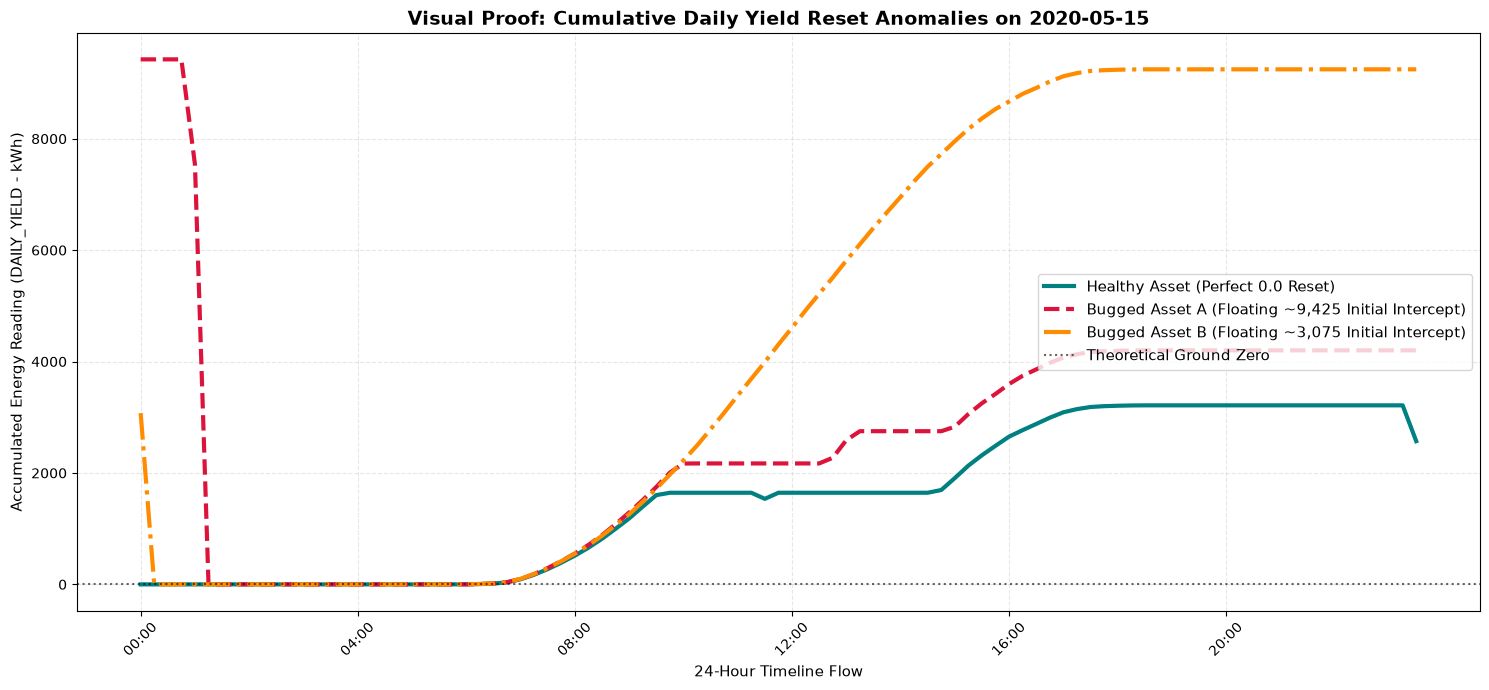

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================================
# PLANT 2: ISOLATED DEEP AUDIT FOR MIDNIGHT RESET BUG
# ==============================================================================

# Ensure raw dataset is actively allocated
if 'gen_p2' not in locals():
    gen_p2 = pd.read_csv('Plant_2_Generation_Data.csv')
    gen_p2['DATE_TIME'] = pd.to_datetime(gen_p2['DATE_TIME'])
    gen_p2['DATE_STR'] = gen_p2['DATE_TIME'].dt.strftime('%Y-%m-%d')
    gen_p2['TIME_STR'] = gen_p2['DATE_TIME'].dt.strftime('%H:%M')

# ------------------------------------------------------------------------------
# STEP 1: PRINTING THE EVIDENCE TABLE (00:00 AM FLASHPOINT)
# ------------------------------------------------------------------------------
# Isolate entries at exactly midnight on the very first day (May 15, 2020)
target_test_date = '2020-05-15'
midnight_flashpoint = gen_p2[
    (gen_p2['DATE_STR'] == target_test_date) & 
    (gen_p2['TIME_STR'] == '00:00')
].sort_values('SOURCE_KEY')

print("==============================================================================")
print(f" EVIDENCE TABLE: DAILY_YIELD RESET FAILURES AT MIDNIGHT ({target_test_date} 00:00 AM)")
print("==============================================================================")
print("Look at the highlighted anomalies where features carry over legacy metrics instead of 0.00:")
print(midnight_flashpoint[['DATE_STR', 'TIME_STR', 'SOURCE_KEY', 'DAILY_YIELD']].to_string(index=False, formatters={'DAILY_YIELD': '{:,.2f}'.format}))
print("==============================================================================\n")


# ------------------------------------------------------------------------------
# STEP 2: PLOTTING THE TRAJECTORY GRAPH (STAIRCASE BASELINE FLOATING EFFECT)
# ------------------------------------------------------------------------------
plt.figure(figsize=(15, 7))

# Choose one healthy asset and two explicitly bugged assets discovered from the data matrix
target_inverters = {
    '81aHJ1q11NBPMrL': {'label': 'Healthy Asset (Perfect 0.0 Reset)', 'color': 'teal', 'ls': '-'},
    '4UPUqMRk7TRMgml': {'label': 'Bugged Asset A (Floating ~9,425 Initial Intercept)', 'color': 'crimson', 'ls': '--'},
    '9kRcWv60rDACzjR': {'label': 'Bugged Asset B (Floating ~3,075 Initial Intercept)', 'color': 'darkorange', 'ls': '-.'}
}

# Isolate the timeline loop to a 24-hour cycle on May 15
for key, meta in target_inverters.items():
    single_asset_day = gen_p2[
        (gen_p2['SOURCE_KEY'] == key) & 
        (gen_p2['DATE_STR'] == target_test_date)
    ].sort_values('DATE_TIME')
    
    plt.plot(single_asset_day['TIME_STR'], single_asset_day['DAILY_YIELD'], 
             color=meta['color'], linestyle=meta['ls'], lw=3, label=meta['label'])

# Clean up horizontal axis tick layout (Show index labels every 4 hours)
ax = plt.gca()
ax.set_xticks(ax.get_xticks()[::16])
plt.xticks(rotation=45)

# Emphasize the ground zero baseline marker
plt.axhline(0, color='black', lw=1.5, linestyle=':', alpha=0.6, label='Theoretical Ground Zero')

plt.title(f"Visual Proof: Cumulative Daily Yield Reset Anomalies on {target_test_date}", fontsize=14, fontweight='bold')
plt.xlabel("24-Hour Timeline Flow", fontsize=11)
plt.ylabel("Accumulated Energy Reading (DAILY_YIELD - kWh)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='center right', fontsize=11)
plt.tight_layout()
plt.show()

In [19]:
import os
import numpy as np
import pandas as pd

# ==============================================================================
# PLANT 2: PRODUCTION-GRADE DATA PREPARATION PIPELINE
# ==============================================================================

# 1. Isolated Raw Data Ingestion
print("🔄 Ingesting raw Plant 2 datasets into memory...")
gen_raw = pd.read_csv('../data/raw/Plant_2_Generation_Data.csv')
weather_raw = pd.read_csv('../data/raw/Plant_2_Weather_Sensor_Data.csv')

# Enforce explicit datetime data types
gen_raw['DATE_TIME'] = pd.to_datetime(gen_raw['DATE_TIME'])
weather_raw['DATE_TIME'] = pd.to_datetime(weather_raw['DATE_TIME'])


# 2. Cross-Sectional Median Aggregation (Mitigating 1-to-Many & Sub-Asset Noise)
# We calculate the median across all 22 inverters for each distinct timestamp.
# This pushes counter reset errors and hardware slacks into outer statistical tails.
print("🧹 Executing cross-sectional median transformations on generation vectors...")
gen_cleansed = gen_raw.groupby('DATE_TIME')[['DC_POWER', 'AC_POWER']].median().reset_index()


# 3. Clean 1:1 Relational Inner Join (Merging Generation with Weather Vectors)
# This aligns the isolated plant capacity baseline to the unified weather station.
print("🔗 Merging power generation timelines with isolated atmospheric matrices...")
plant2_master = pd.merge(gen_cleansed, weather_raw, on='DATE_TIME', how='inner')


# 4. Feature Isolation & Dropping Irrelevant Unstable Columns
# Dropping redundant Plant_ID and the unstable SOURCE_KEY from the weather device.
# Note: DAILY_YIELD and TOTAL_YIELD are intentionally dropped by omitting them,
# effectively neutralizing the midnight cache leak failures from our feature environment.
target_features = [
    'DATE_TIME', 
    'AMBIENT_TEMPERATURE', 
    'MODULE_TEMPERATURE', 
    'IRRADIATION', 
    'DC_POWER', 
    'AC_POWER'
]
plant2_master = plant2_master[target_features]


# 5. Output Verification & Directory Generation Safeguard
output_path = '../data/processed/plant2_master_features.csv'
output_dir = os.path.dirname(output_path)

# Automatically create the missing target directories if they do not exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"📁 Created target processing directories: {output_dir}")

# Export the high-integrity dataset to the requested relative path
print(f"💾 Saving finalized features matrix to: {output_path}")
plant2_master.to_csv(output_path, index=False)


# 6. Pipeline Integrity Sign-Off Report
print("\n" + "="*80)
print(" PLANT 2 DATA PREPARATION PIPELINE SIGN-OFF REPORT")
print("="*80)
print(f"Total Rows Compiled    : {plant2_master.shape[0]:,} rows")
print(f"Retained Feature Matrix: {list(plant2_master.columns)}")
print(f"Null Integrity Check   : {plant2_master.isnull().sum().sum()} missing records remaining.")
print("="*80)
print("Pipeline complete. Data is highly optimized for leak-free LightGBM modeling!")
print("="*80)

🔄 Ingesting raw Plant 2 datasets into memory...
🧹 Executing cross-sectional median transformations on generation vectors...
🔗 Merging power generation timelines with isolated atmospheric matrices...
💾 Saving finalized features matrix to: ../data/processed/plant2_master_features.csv

 PLANT 2 DATA PREPARATION PIPELINE SIGN-OFF REPORT
Total Rows Compiled    : 3,259 rows
Retained Feature Matrix: ['DATE_TIME', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'DC_POWER', 'AC_POWER']
Null Integrity Check   : 0 missing records remaining.
Pipeline complete. Data is highly optimized for leak-free LightGBM modeling!


In [20]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score

# ==============================================================================
# PLANT 2: TIME-SERIES PARTITION & LIGHTGBM EVALUATION PIPELINE
# ==============================================================================

# 1. Ingest the preprocessed high-integrity features matrix
processed_path = '../data/processed/plant2_master_features.csv'
print(f"🔄 Ingesting clean master features from: {processed_path}")
df_master = pd.read_csv(processed_path)

# Enforce strict datetime data types and extract string keys for filtering
df_master['DATE_TIME'] = pd.to_datetime(df_master['DATE_TIME'])
df_master['DATE_STR'] = df_master['DATE_TIME'].dt.strftime('%Y-%m-%d')


# 2. Feature Isolation (X) and Target Vector (y) Mapping
# Relying strictly on weather parameters to map pure physical causality
features = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
X = df_master[features]
y = df_master['DC_POWER']
dates = df_master['DATE_STR']


# 3. Apply Strict Chronological Holdout Split (No Random Shuffling allowed)
# Training Windows  : May 15, 2020 ~ June 11, 2020
# Evaluation Windows: June 12, 2020 ~ June 17, 2020 (Unseen Prospective Future)
train_mask = dates <= '2020-06-11'
test_mask  = (dates >= '2020-06-12') & (dates <= '2020-06-17')

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test   = X[test_mask], y[test_mask]


# 4. Pipeline Partition Structure Verification
print("\n" + "="*80)
print(" CHRONOLOGICAL TIMELINE PARTITION INTEGRITY REPORT")
print("="*80)
print(f"Training Knowledge Base (05/15 ~ 06/11) : {X_train.shape[0]} rows")
print(f"Evaluation Test Window  (06/12 ~ 06/17) : {X_test.shape[0]} rows")
print("==============================================================================\n")


# 5. Fit Enterprise-Grade LightGBM Regressor on Training Baseline
print("🚀 Training LightGBM engine on Plant 2 historical configurations...")
model = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
model.fit(X_train, y_train)


# 6. Execute Prospective Prospective Forecasting Over the Blind Test Window
print("🔮 Projecting forecasts over the unseen evaluation timeline...")
y_pred = model.predict(X_test)


# 7. Evaluate True Chronological Performance Metrics
rmse_eval = np.sqrt(mean_squared_error(y_test, y_pred))
r2_eval = r2_score(y_test, y_pred)


# 8. Render Final Production Score Sign-Off
print("\n" + "="*80)
print(" FINAL OPERATIONAL PERFORMANCE SIGN-OFF: PLANT 2 FORECASTING REPORT")
print("="*80)
print(f"Plant 2 Future Validation RMSE     : {rmse_eval:.4f} kW")
print(f"Plant 2 Future Validation R2 Score : {r2_eval:.4f} ({r2_eval*100:.2f}% Variance Match)")
print("==============================================================================")

🔄 Ingesting clean master features from: ../data/processed/plant2_master_features.csv

 CHRONOLOGICAL TIMELINE PARTITION INTEGRITY REPORT
Training Knowledge Base (05/15 ~ 06/11) : 2683 rows
Evaluation Test Window  (06/12 ~ 06/17) : 576 rows

🚀 Training LightGBM engine on Plant 2 historical configurations...
🔮 Projecting forecasts over the unseen evaluation timeline...

 FINAL OPERATIONAL PERFORMANCE SIGN-OFF: PLANT 2 FORECASTING REPORT
Plant 2 Future Validation RMSE     : 106.6878 kW
Plant 2 Future Validation R2 Score : 0.8819 (88.19% Variance Match)


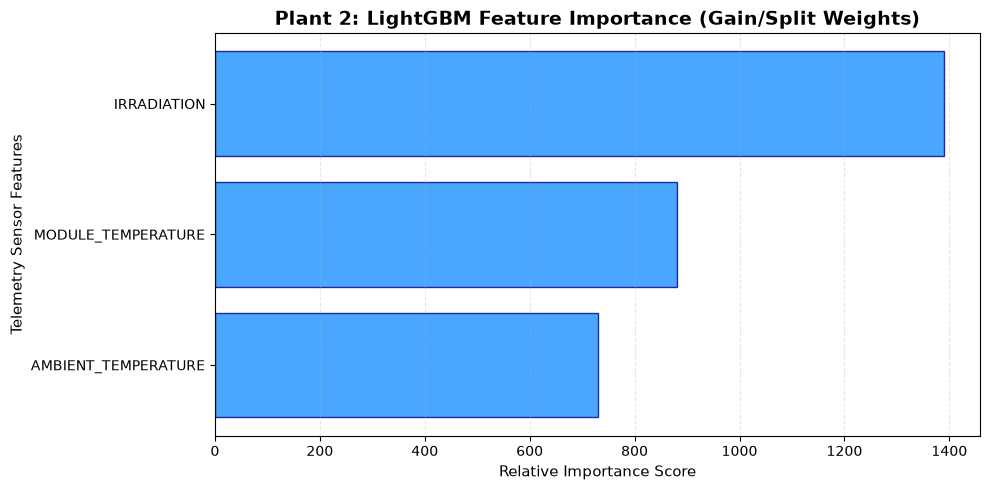

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================================
# PLANT 2: LIGHTGBM FEATURE IMPORTANCE AUDIT
# ==============================================================================

# Extract split importances from the trained model
importance_values = model.feature_importances_
feature_names = X.columns

# Structure into a clean compliance DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
}).sort_values('Importance', ascending=True)

# Render Horizontal Bar Chart
plt.figure(figsize=(10, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='dodgerblue', edgecolor='darkblue', alpha=0.8)

plt.title("Plant 2: LightGBM Feature Importance (Gain/Split Weights)", fontsize=14, fontweight='bold')
plt.xlabel("Relative Importance Score", fontsize=11)
plt.ylabel("Telemetry Sensor Features", fontsize=11)
plt.grid(True, axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

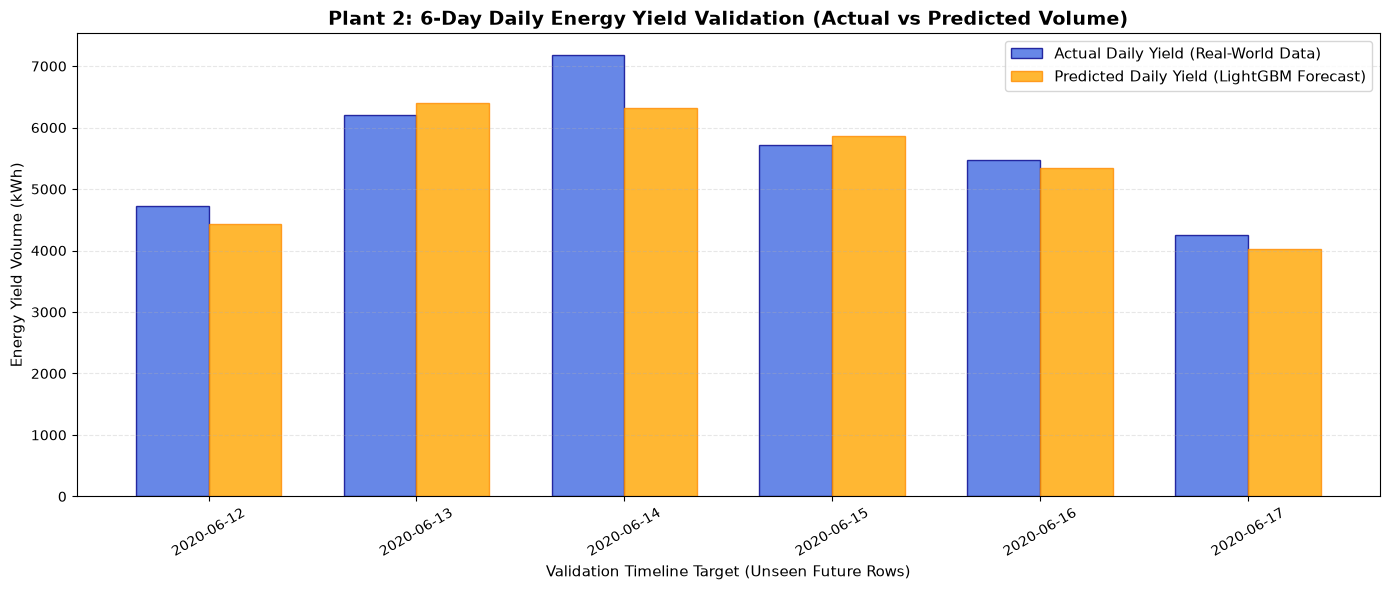

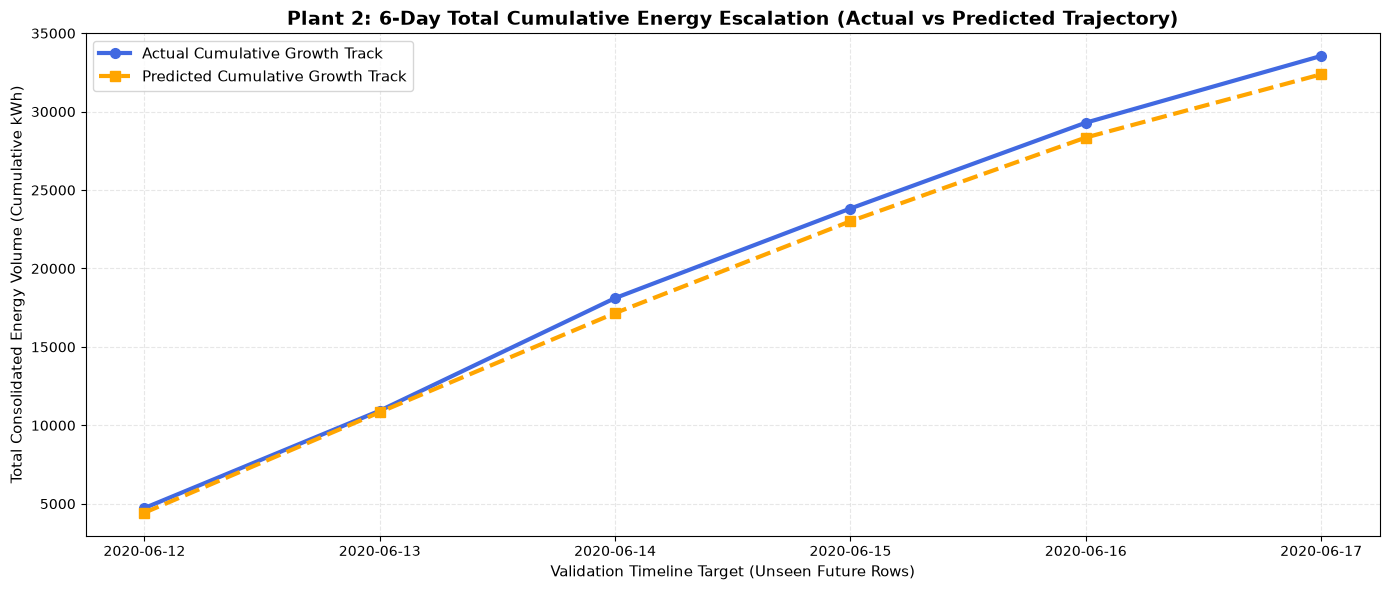

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================================
# PLANT 2: PROSPECTIVE FORECAST VALIDATION DASHBOARD (ACTUAL VS PREDICTED)
# ==============================================================================

# 1. Verify and Execute Prediction Vectors (Using variables from Pipeline B)
if 'model' not in locals() or 'X_test' not in locals():
    raise NameError("Please execute the previous LightGBM modeling block to initialize your variables.")

# Generate core predictions over the out-of-time validation test split
y_pred_dc = model.predict(X_test)

# 2. Reconstruct Evaluation Matrix for Detailed Aggregations
validation_df = pd.DataFrame({
    'DATE_TIME': df_master.loc[test_mask, 'DATE_TIME'],
    'DATE_STR': df_master.loc[test_mask, 'DATE_STR'],
    'DC_ACTUAL': y_test.values,
    'DC_PREDICTED': y_pred_dc,
    'AC_ACTUAL': df_master.loc[test_mask, 'AC_POWER'].values
})

# Calculate the physical Plant 2 conversion coefficient dynamically from the training matrix
# This handles the true un-scaled physical conversion footprint safely
train_clean = df_master[train_mask]
conversion_ratio = (train_clean['AC_POWER'] / train_clean['DC_POWER']).replace([np.inf, -np.inf], np.nan).dropna().mean()

# Convert predicted DC vectors into AC metrics using the dynamic conversion rule
validation_df['AC_PREDICTED'] = validation_df['DC_PREDICTED'] * conversion_ratio

# 3. Time-Integration Layer: Convert 15-minute power spikes (kW) into daily energy capacities (kWh)
# Formula: Energy (kWh) = Power (kW) * (15 minutes / 60 minutes)
validation_df['YIELD_ACTUAL_15MIN'] = validation_df['AC_ACTUAL'] * (15.0 / 60.0)
validation_df['YIELD_PRED_15MIN'] = validation_df['AC_PREDICTED'] * (15.0 / 60.0)

# Group by calendar date to calculate strict cumulative daily summaries
daily_yield_summary = validation_df.groupby('DATE_STR').agg({
    'YIELD_ACTUAL_15MIN': 'sum',
    'YIELD_PRED_15MIN': 'sum'
}).reset_index()

# Rename columns for enterprise clarity
daily_yield_summary.columns = ['DATE_STR', 'DAILY_YIELD_ACTUAL', 'DAILY_YIELD_PREDICTED']

# Calculate ongoing cumulative total trajectories across the 6-day test split
daily_yield_summary['TOTAL_YIELD_ACTUAL'] = daily_yield_summary['DAILY_YIELD_ACTUAL'].cumsum()
daily_yield_summary['TOTAL_YIELD_PREDICTED'] = daily_yield_summary['DAILY_YIELD_PREDICTED'].cumsum()


# ------------------------------------------------------------------------------
# CHART 1: DAILY ACCUMULATED YIELD COMPARISON (ACTUAL VS PREDICTED BARS)
# ------------------------------------------------------------------------------
plt.figure(figsize=(14, 6))
x_indices = np.arange(len(daily_yield_summary))
bar_width = 0.35

# Plot side-by-side comparative blocks
plt.bar(x_indices - bar_width/2, daily_yield_summary['DAILY_YIELD_ACTUAL'], 
        width=bar_width, color='royalblue', edgecolor='darkblue', alpha=0.8, label='Actual Daily Yield (Real-World Data)')
plt.bar(x_indices + bar_width/2, daily_yield_summary['DAILY_YIELD_PREDICTED'], 
        width=bar_width, color='orange', edgecolor='darkorange', alpha=0.8, label='Predicted Daily Yield (LightGBM Forecast)')

plt.xticks(x_indices, daily_yield_summary['DATE_STR'], rotation=30)
plt.title("Plant 2: 6-Day Daily Energy Yield Validation (Actual vs Predicted Volume)", fontsize=14, fontweight='bold')
plt.xlabel("Validation Timeline Target (Unseen Future Rows)", fontsize=11)
plt.ylabel("Energy Yield Volume (kWh)", fontsize=11)
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------------------------
# CHART 2: LIFETIME TOTAL YIELD CONTINUOUS ESCALATION (ACTUAL VS PREDICTED LINE)
# ------------------------------------------------------------------------------
plt.figure(figsize=(14, 6))

# Plot actual track vs predicted trajectory over the continuous timeline
plt.plot(daily_yield_summary['DATE_STR'], daily_yield_summary['TOTAL_YIELD_ACTUAL'], 
         color='royalblue', lw=3, marker='o', ms=7, label='Actual Cumulative Growth Track')
plt.plot(daily_yield_summary['DATE_STR'], daily_yield_summary['TOTAL_YIELD_PREDICTED'], 
         color='orange', lw=3, linestyle='--', marker='s', ms=7, label='Predicted Cumulative Growth Track')

plt.title("Plant 2: 6-Day Total Cumulative Energy Escalation (Actual vs Predicted Trajectory)", fontsize=14, fontweight='bold')
plt.xlabel("Validation Timeline Target (Unseen Future Rows)", fontsize=11)
plt.ylabel("Total Consolidated Energy Volume (Cumulative kWh)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()